In [2]:
# Core Python
import numpy as np
import pandas as pd
import random
import json
import joblib
import os

# Visualization

import matplotlib.pyplot as plt

# Preprocessing / ML

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)


# TensorFlow / Keras

import tensorflow as tf

from tensorflow.keras.models import Model, Sequential, load_model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Reshape,
    Input,
    LSTM,
    GRU,
    Bidirectional,
    Conv1D,
    GlobalAveragePooling1D,
    Add,
    Concatenate,
    Layer
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.losses import Huber

# Reproducibility (GLOBAL SEED)

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# System Info

print("All Imports Loaded Successfully")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

All Imports Loaded Successfully
Num GPUs Available: 0


In [3]:
df=pd.read_csv('C:/Users/nicke/Desktop/PredictionofAirTemperature/central_west_dataset/central_west.csv')
df

,index,date,hour,precipitation_mm,pressure_station_mb,pressure_max_prev_hour_mb,pressure_min_prev_hour_mb,solar_radiation_kj_m2,air_temp_c,dew_point_temp_c,...,wind_direction_deg,wind_gust_max_mps,wind_speed_mps,region,state,station,station_code,latitude,longitude,height_m
0,138998,20-12-2017,14:00,0.0,899.6,900.0,899.6,3391,26.5,17.7,...,39,9.6,3.9,CO,DF,PARANOA (COOPA-DF),A047,-16.011111,-47.557500,1043.0
1,138999,20-12-2017,15:00,0.0,899.2,899.6,899.2,3306,26.6,16.7,...,55,8.3,3.4,CO,DF,PARANOA (COOPA-DF),A047,-16.011111,-47.557500,1043.0
2,139000,20-12-2017,16:00,0.0,898.6,899.2,898.6,3167,27.3,15.8,...,62,8.3,3.6,CO,DF,PARANOA (COOPA-DF),A047,-16.011111,-47.557500,1043.0
3,139001,20-12-2017,17:00,0.0,897.7,898.6,897.7,3279,27.5,12.9,...,43,6.7,3.1,CO,DF,PARANOA (COOPA-DF),A047,-16.011111,-47.557500,1043.0
4,139002,20-12-2017,18:00,0.0,897.0,897.7,897.0,2753,27.5,13.7,...,98,6.4,3.5,CO,DF,PARANOA (COOPA-DF),A047,-16.011111,-47.557500,1043.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,212883,30-11-2018,03:00,2.6,925.5,926.6,925.4,-9999,21.2,20.8,...,360,2.5,0.0,CO,MT,ITIQUIRA,A933,-17.297222,-54.837222,585.0
1048571,212884,30-11-2018,04:00,0.8,925.4,925.7,925.4,-9999,21.2,20.8,...,18,0.5,0.0,CO,MT,ITIQUIRA,A933,-17.297222,-54.837222,585.0
1048572,212885,30-11-2018,05:00,0.4,925.6,925.7,925.4,-9999,21.2,20.8,...,30,0.0,0.0,CO,MT,ITIQUIRA,A933,-17.297222,-54.837222,585.0
1048573,212886,30-11-2018,06:00,0.6,926.0,926.0,925.6,-9999,21.3,20.9,...,38,0.0,0.0,CO,MT,ITIQUIRA,A933,-17.297222,-54.837222,585.0


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Shape of Dataset:
(1048575, 27)

Column Names:
['index', 'date', 'hour', 'precipitation_mm', 'pressure_station_mb', 'pressure_max_prev_hour_mb', 'pressure_min_prev_hour_mb', 'solar_radiation_kj_m2', 'air_temp_c', 'dew_point_temp_c', 'temp_max_prev_hour_c', 'temp_min_prev_hour_c', 'dew_temp_max_prev_hour_c', 'dew_temp_min_prev_hour_c', 'humidity_max_prev_hour_percent', 'humidity_min_prev_hour_percent', 'humidity_percent', 'wind_direction_deg', 'wind_gust_max_mps', 'wind_speed_mps', 'region', 'state', 'station', 'station_code', 'latitude', 'longitude', 'height_m']


In [5]:
# Handling wrong sensor values
df = df.replace(-9999, np.nan)

df = df.dropna(subset=['air_temp_c'])

df['solar_radiation_kj_m2'] = df['solar_radiation_kj_m2'].fillna(0)
df['precipitation_mm'] = df['precipitation_mm'].fillna(0)



In [6]:
df['datetime'] = pd.to_datetime(
    df['date'] + ' ' + df['hour'],
    format='%d-%m-%Y %H:%M'
)

df = df.sort_values(['station_code', 'datetime'])


# Lag Features
df['temp_lag_1'] = df.groupby('station_code')['air_temp_c'].shift(1)
df['temp_lag_2'] = df.groupby('station_code')['air_temp_c'].shift(2)
df['temp_lag_3'] = df.groupby('station_code')['air_temp_c'].shift(3)

# Interpolation
interp_cols = [
    'pressure_station_mb',
    'dew_point_temp_c',
    'humidity_percent'
]

df[interp_cols] = df.groupby('station_code')[interp_cols].transform(
    lambda x: x.interpolate().bfill().ffill()
)

df = df.dropna(subset=[
    'temp_lag_1','temp_lag_2','temp_lag_3'
])

In [7]:
df['month'] = df['datetime'].dt.month
df['dayofyear'] = df['datetime'].dt.dayofyear

df['hour_sin'] = np.sin(2*np.pi*df['datetime'].dt.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df['datetime'].dt.hour/24)

df['doy_sin'] = np.sin(2*np.pi*df['dayofyear']/365)
df['doy_cos'] = np.cos(2*np.pi*df['dayofyear']/365)

In [8]:
# -------- PHYSICAL LIMIT FILTERING --------
df = df[(df['air_temp_c'] >= -15) & (df['air_temp_c'] <= 60)]
df = df[(df['pressure_station_mb'] >= 850) & (df['pressure_station_mb'] <= 1100)]
df = df[(df['humidity_percent'] >= 0) & (df['humidity_percent'] <= 100)]
df = df[(df['wind_speed_mps'] >= 0) & (df['wind_speed_mps'] <= 60)]
# -------- SPIKE DETECTION --------
df['temp_change'] = df.groupby('station_code')['air_temp_c'].diff().abs()

df = df[df['temp_change'] < 10]

df = df.drop(columns=['temp_change'])

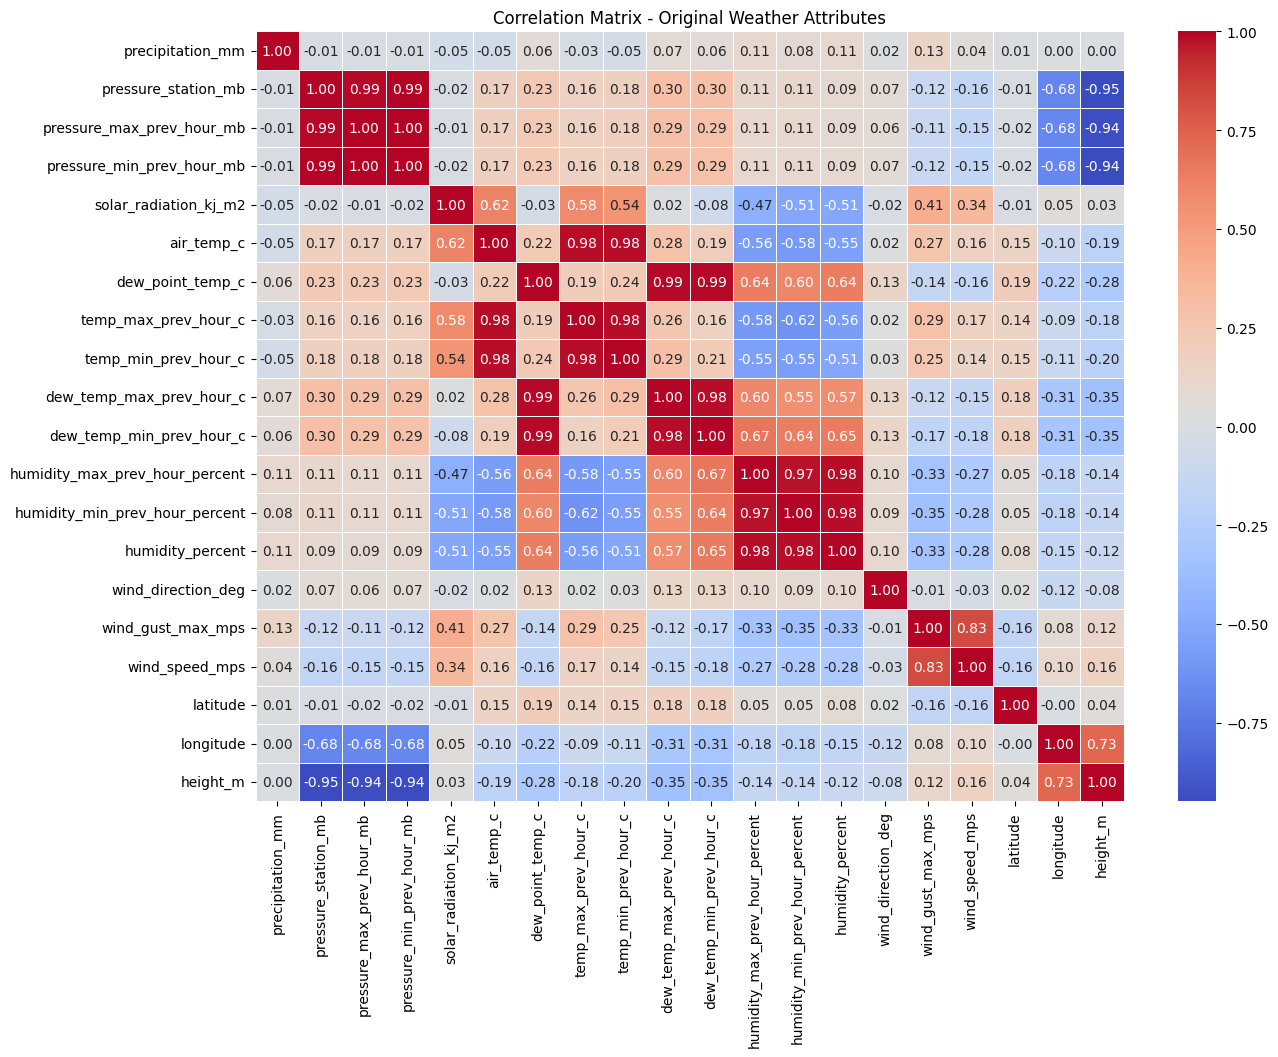

In [9]:
import seaborn as sns
original_columns = [
    'precipitation_mm',
    'pressure_station_mb',
    'pressure_max_prev_hour_mb',
    'pressure_min_prev_hour_mb',
    'solar_radiation_kj_m2',
    'air_temp_c',
    'dew_point_temp_c',
    'temp_max_prev_hour_c',
    'temp_min_prev_hour_c',
    'dew_temp_max_prev_hour_c',
    'dew_temp_min_prev_hour_c',
    'humidity_max_prev_hour_percent',
    'humidity_min_prev_hour_percent',
    'humidity_percent',
    'wind_direction_deg',
    'wind_gust_max_mps',
    'wind_speed_mps',
    'latitude',
    'longitude',
    'height_m'
]
corr_df = df[original_columns]
corr_matrix = corr_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix - Original Weather Attributes")

plt.show()


In [10]:
final_cols = [
'temp_lag_1','temp_lag_2','temp_lag_3',
'dew_point_temp_c',
'solar_radiation_kj_m2',
'humidity_percent',
'pressure_station_mb',
'wind_speed_mps',
'height_m','latitude','longitude',
'hour_sin','hour_cos',
'doy_sin','doy_cos',
'month',
'air_temp_c'
]

df = df[final_cols].copy()

df = df.reset_index(drop=True)

In [11]:
features = [
'temp_lag_1','temp_lag_2','temp_lag_3',
'dew_point_temp_c',
'solar_radiation_kj_m2',
'humidity_percent',
'pressure_station_mb',
'wind_speed_mps',
'height_m','latitude','longitude',
'hour_sin','hour_cos',
'doy_sin','doy_cos',
'month'
]

target = 'air_temp_c'


In [12]:
X = df[features]
y = df[target]

split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))


In [13]:
def create_sequences(X, y, window=24):
    Xs, ys = [], []
    for i in range(len(X)-window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled)


In [14]:
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)


X_train_seq shape: (741173, 24, 16)
y_train_seq shape: (741173, 1)
X_test_seq shape: (185276, 24, 16)
y_test_seq shape: (185276, 1)


In [15]:

# IEEE GLOBAL STYLE CONFIG

import matplotlib.pyplot as plt
import matplotlib as mpl

def _set_ieee_style(single_column=True):

    if single_column:
        width = 3.5   # inches
    else:
        width = 7.16  # double column

    height = width * 0.6

    mpl.rcParams.update({
        "figure.figsize": (width, height),
        "figure.dpi": 300,

        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,

        "xtick.labelsize": 9,
        "ytick.labelsize": 9,

        "legend.fontsize": 9,

        "lines.linewidth": 2.2,

        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.6,

        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.format": "pdf"
    })

In [16]:
def evaluate_regression_metrics(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    print("\n📊 Model Evaluation Metrics")
    print("----------------------------")
    print(f"MSE  : {mse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R2   : {r2:.4f}")

    return {
        "MSE": float(mse),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE": float(mape),
        "R2": float(r2)
    }

In [17]:
def plot_loss(history, model_name="Model"):

    plt.figure(figsize=(10, 5))
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [18]:
def plot_actual_vs_predicted(
    y_true,
    y_pred,
    model_name="Model",
    n_points=400,
    step=2,
    save_path=None
):

    _set_ieee_style(single_column=False)

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    y_true = y_true[:n_points:step]
    y_pred = y_pred[:n_points:step]

    plt.figure()

    plt.plot(y_true, label="Actual", linewidth=2.5)
    plt.plot(y_pred, linestyle="--", label="Predicted", linewidth=2.2)

    plt.xlabel("Time Step")
    plt.ylabel("Temperature (°C)")

    plt.title(f"{model_name} - Actual vs Predicted Values")

    plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

    if save_path:
        plt.savefig(save_path)

    plt.show()

In [33]:
#LSTM MODEL
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

model_lstm_final = Sequential()

model_lstm_final.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# BLOCK 1
model_lstm_final.add(LSTM(128, return_sequences=True))
model_lstm_final.add(BatchNormalization())
model_lstm_final.add(Dropout(0.25))   

# BLOCK 2
model_lstm_final.add(LSTM(64, return_sequences=True))
model_lstm_final.add(BatchNormalization())
model_lstm_final.add(Dropout(0.25))   

# BLOCK 3
model_lstm_final.add(LSTM(48))         
model_lstm_final.add(Dropout(0.2))

# DENSE
model_lstm_final.add(Dense(64, activation='relu'))
model_lstm_final.add(Dropout(0.2))
model_lstm_final.add(Dense(32, activation='relu'))
model_lstm_final.add(Dense(16, activation='relu'))   
model_lstm_final.add(Dense(1))

#compile
optimizer = Adam(learning_rate=0.0005)

model_lstm_final.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)
#CALLBACKS
#Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)
#Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)
#Save Best Model During Training
checkpoint = ModelCheckpoint(
    "models/best_lstm_weather_model.keras",
    monitor='val_loss',
    save_best_only=True
)
#Training
history_lstm = model_lstm_final.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,          
    batch_size=128,     
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=2
)
#Prediction
y_pred_lstm = model_lstm_final.predict(X_test_seq)

y_pred_lstm_actual = scaler_y.inverse_transform(y_pred_lstm)
y_test_actual = scaler_y.inverse_transform(y_test_seq)
#Evaluation
metrics_lstm = evaluate_regression_metrics(
    y_test_actual,
    y_pred_lstm_actual
)
#Save model
model_lstm_final.save("models/lstm_temperature_model_final.keras")
#save metrics
with open("metrics/lstm_metrics.json", "w") as f:
    json.dump(metrics_lstm, f, indent=4)
#save history
joblib.dump(
    history_lstm.history,
    "history/lstm_history.pkl"
)


Epoch 1/50
5791/5791 - 515s - 89ms/step - loss: 0.0031 - mae: 0.0347 - val_loss: 0.0029 - val_mae: 0.0480 - learning_rate: 5.0000e-04
Epoch 2/50
5791/5791 - 495s - 85ms/step - loss: 7.7125e-04 - mae: 0.0199 - val_loss: 9.5042e-04 - val_mae: 0.0222 - learning_rate: 5.0000e-04
Epoch 3/50
5791/5791 - 488s - 84ms/step - loss: 6.5764e-04 - mae: 0.0181 - val_loss: 8.4442e-04 - val_mae: 0.0207 - learning_rate: 5.0000e-04
Epoch 4/50
5791/5791 - 492s - 85ms/step - loss: 6.0557e-04 - mae: 0.0172 - val_loss: 8.6959e-04 - val_mae: 0.0218 - learning_rate: 5.0000e-04
Epoch 5/50
5791/5791 - 487s - 84ms/step - loss: 5.7536e-04 - mae: 0.0166 - val_loss: 7.7152e-04 - val_mae: 0.0200 - learning_rate: 5.0000e-04
Epoch 6/50
5791/5791 - 491s - 85ms/step - loss: 5.5393e-04 - mae: 0.0162 - val_loss: 9.3611e-04 - val_mae: 0.0230 - learning_rate: 5.0000e-04
Epoch 7/50
5791/5791 - 487s - 84ms/step - loss: 5.3905e-04 - mae: 0.0159 - val_loss: 8.4381e-04 - val_mae: 0.0220 - learning_rate: 5.0000e-04
Epoch 8/50
579

['history/lstm_history.pkl']

In [19]:

# LOAD MODEL

model_lstm = load_model("models/lstm_temperature_model_final.keras")
print(" LSTM Model Loaded Successfully")

print("\n📊 Model Summary:")
model_lstm.summary()


# LOAD HISTORY

history_lstm = joblib.load("history/lstm_history.pkl")
print("\n LSTM History Loaded Successfully")

print("\n History Keys:")
print(history_lstm.keys())

# LOAD METRICS

with open("metrics/lstm_metrics.json") as f:
    metrics_lstm = json.load(f)

print("\n LSTM Metrics Loaded Successfully")

print("\n Metrics Values:")
for k, v in metrics_lstm.items():
    print(f"{k} : {v}")


 LSTM Model Loaded Successfully

📊 Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 24, 128)             │          74,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 24, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 24, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 24, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 48)                  │          21,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 454,853 (1.74 MB)

 Trainable params: 151,489 (591.75 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 302,980 (1.16 MB)


 LSTM History Loaded Successfully

 History Keys:
dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

 LSTM Metrics Loaded Successfully

 Metrics Values:
MSE : 1.6754064973119436
MAE : 0.9337803033836429
RMSE : 1.2943749446400543
MAPE : 4.170042390018425
R2 : 0.9307409085903066


5790/5790 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step


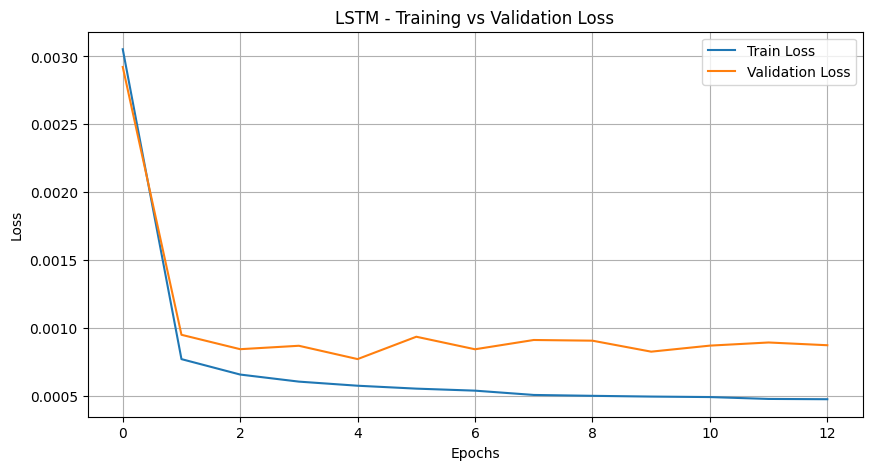

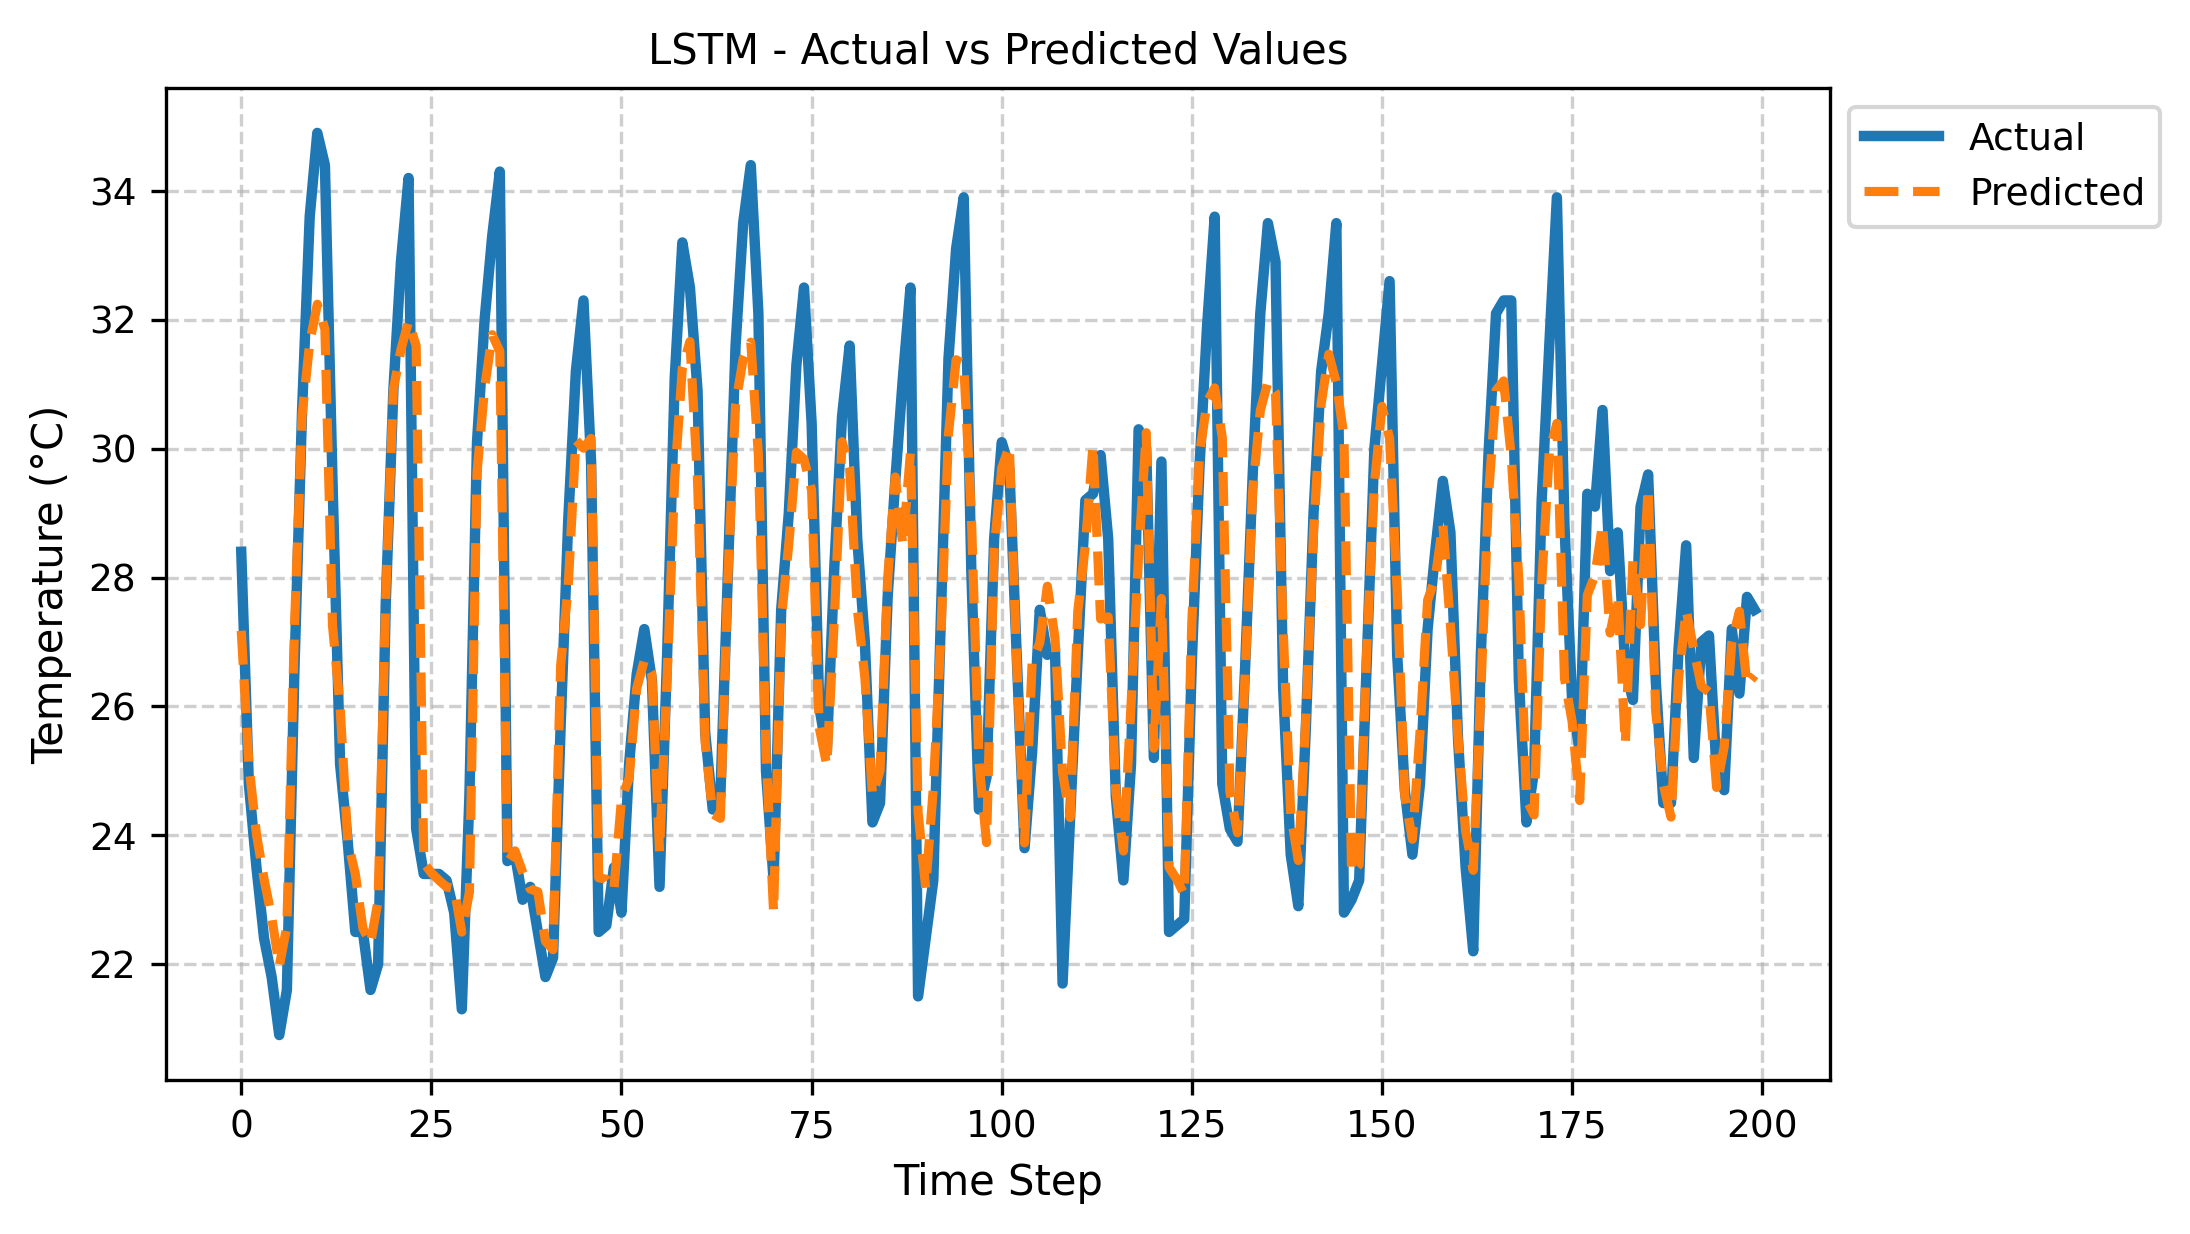

In [12]:
# 1. Load model
model_lstm = load_model("models/lstm_temperature_model_final.keras")

# 2. Load history
history_lstm = joblib.load("history/lstm_history.pkl")

# 3. Generate predictions (VERY IMPORTANT)
y_pred_lstm = model_lstm.predict(X_test_seq)

# 4. Inverse scaling
y_pred_lstm_actual = scaler_y.inverse_transform(y_pred_lstm)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

# 5. Plot
plot_loss(history_lstm, "LSTM")

plot_actual_vs_predicted(
    y_test_actual,
    y_pred_lstm_actual,
    "LSTM"
)

In [ ]:

# GRU OPTIMIZED MODEL

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

model_gru_opt = Sequential()

model_gru_opt.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# BLOCK 1

model_gru_opt.add(GRU(
    128,
    return_sequences=True,
    recurrent_dropout=0.1
))

model_gru_opt.add(BatchNormalization())
model_gru_opt.add(Dropout(0.2))

# BLOCK 2

model_gru_opt.add(GRU(
    64,
    return_sequences=True,
    recurrent_dropout=0.1
))

model_gru_opt.add(BatchNormalization())
model_gru_opt.add(Dropout(0.2))


# BLOCK 3

model_gru_opt.add(GRU(
    32
))

model_gru_opt.add(Dropout(0.15))


# DENSE HEAD

model_gru_opt.add(Dense(64, activation='relu'))
model_gru_opt.add(Dropout(0.15))

model_gru_opt.add(Dense(32, activation='relu'))
model_gru_opt.add(Dense(16, activation='relu'))

model_gru_opt.add(Dense(1))


# COMPILE

optimizer = Adam(
    learning_rate=2e-4,
    clipnorm=1.0
)

model_gru_opt.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)


# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "models/best_gru_weather_model_opt.keras",
    monitor='val_mae',
    save_best_only=True
)


# TRAINING

history_gru = model_gru_opt.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=60,
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=2
)


# PREDICTION

y_pred_gru = model_gru_opt.predict(X_test_seq)

y_pred_gru_actual = scaler_y.inverse_transform(y_pred_gru)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# EVALUATION


metrics_gru = evaluate_regression_metrics(
    y_test_actual,
    y_pred_gru_actual
)


# SAVE MODEL


model_gru_opt.save("models/gru_temperature_model_final.keras")

with open("metrics/gru_metrics.json", "w") as f:
    json.dump(metrics_gru, f, indent=4)

joblib.dump(
    history_gru.history,
    "history/gru_history.pkl"
)

print(" Optimized GRU Model Saved")

In [21]:

# LOAD MODEL


model_gru = load_model("models/gru_temperature_model_final.keras")

print(" Optimized GRU Model Loaded Successfully")

print("\n Model Summary:")
model_gru.summary()


# LOAD HISTORY


history_gru = joblib.load("history/gru_history.pkl")

print("\n GRU History Loaded Successfully")

print("\n History Keys:")
print(history_gru.keys())


# LOAD METRICS


with open("metrics/gru_metrics.json") as f:
    metrics_gru = json.load(f)

print("\n GRU Metrics Loaded Successfully")

print("\n Metrics Values:")
for k, v in metrics_gru.items():
    print(f"{k} : {v}")

 Optimized GRU Model Loaded Successfully

 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 24, 128)             │          56,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 24, 64)              │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 323,909 (1.24 MB)

 Trainable params: 107,841 (421.25 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 215,684 (842.52 KB)


 GRU History Loaded Successfully

 History Keys:
dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

 GRU Metrics Loaded Successfully

 Metrics Values:
MSE : 2.284941663913223
MAE : 1.1646672555167454
RMSE : 1.5116023497974667
MAPE : 5.05793546263733
R2 : 0.9055435299906696


5790/5790 ━━━━━━━━━━━━━━━━━━━━ 73s 12ms/step


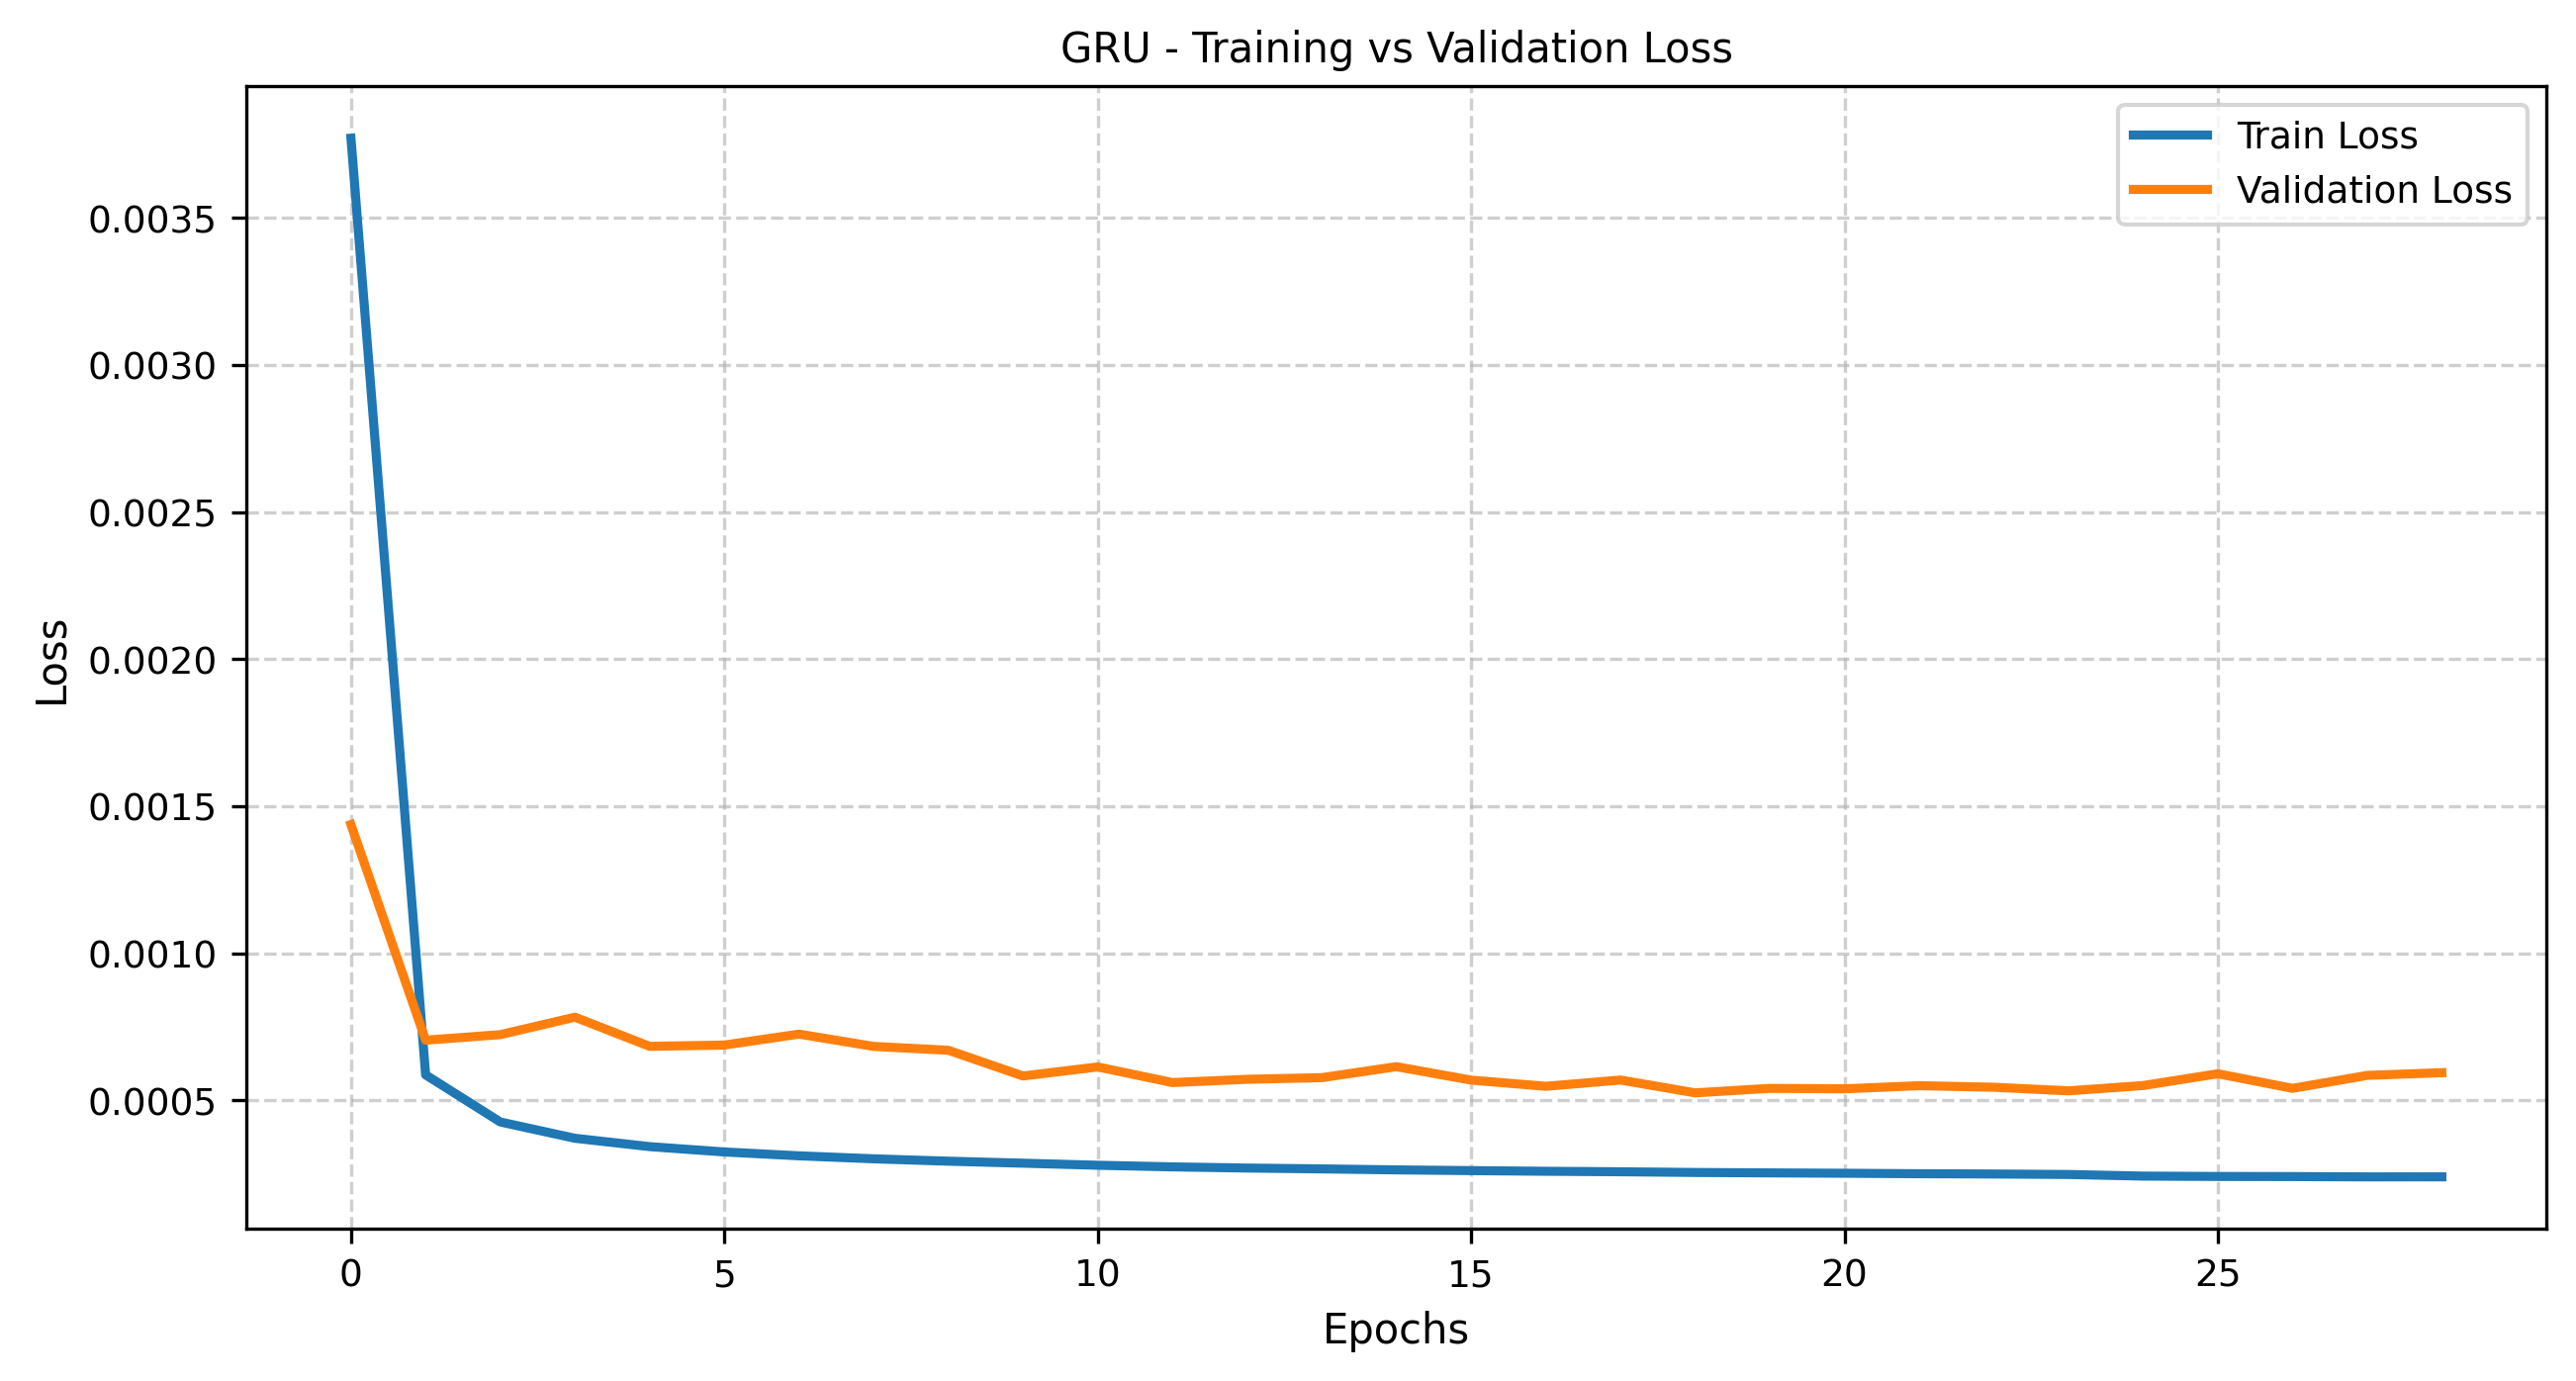

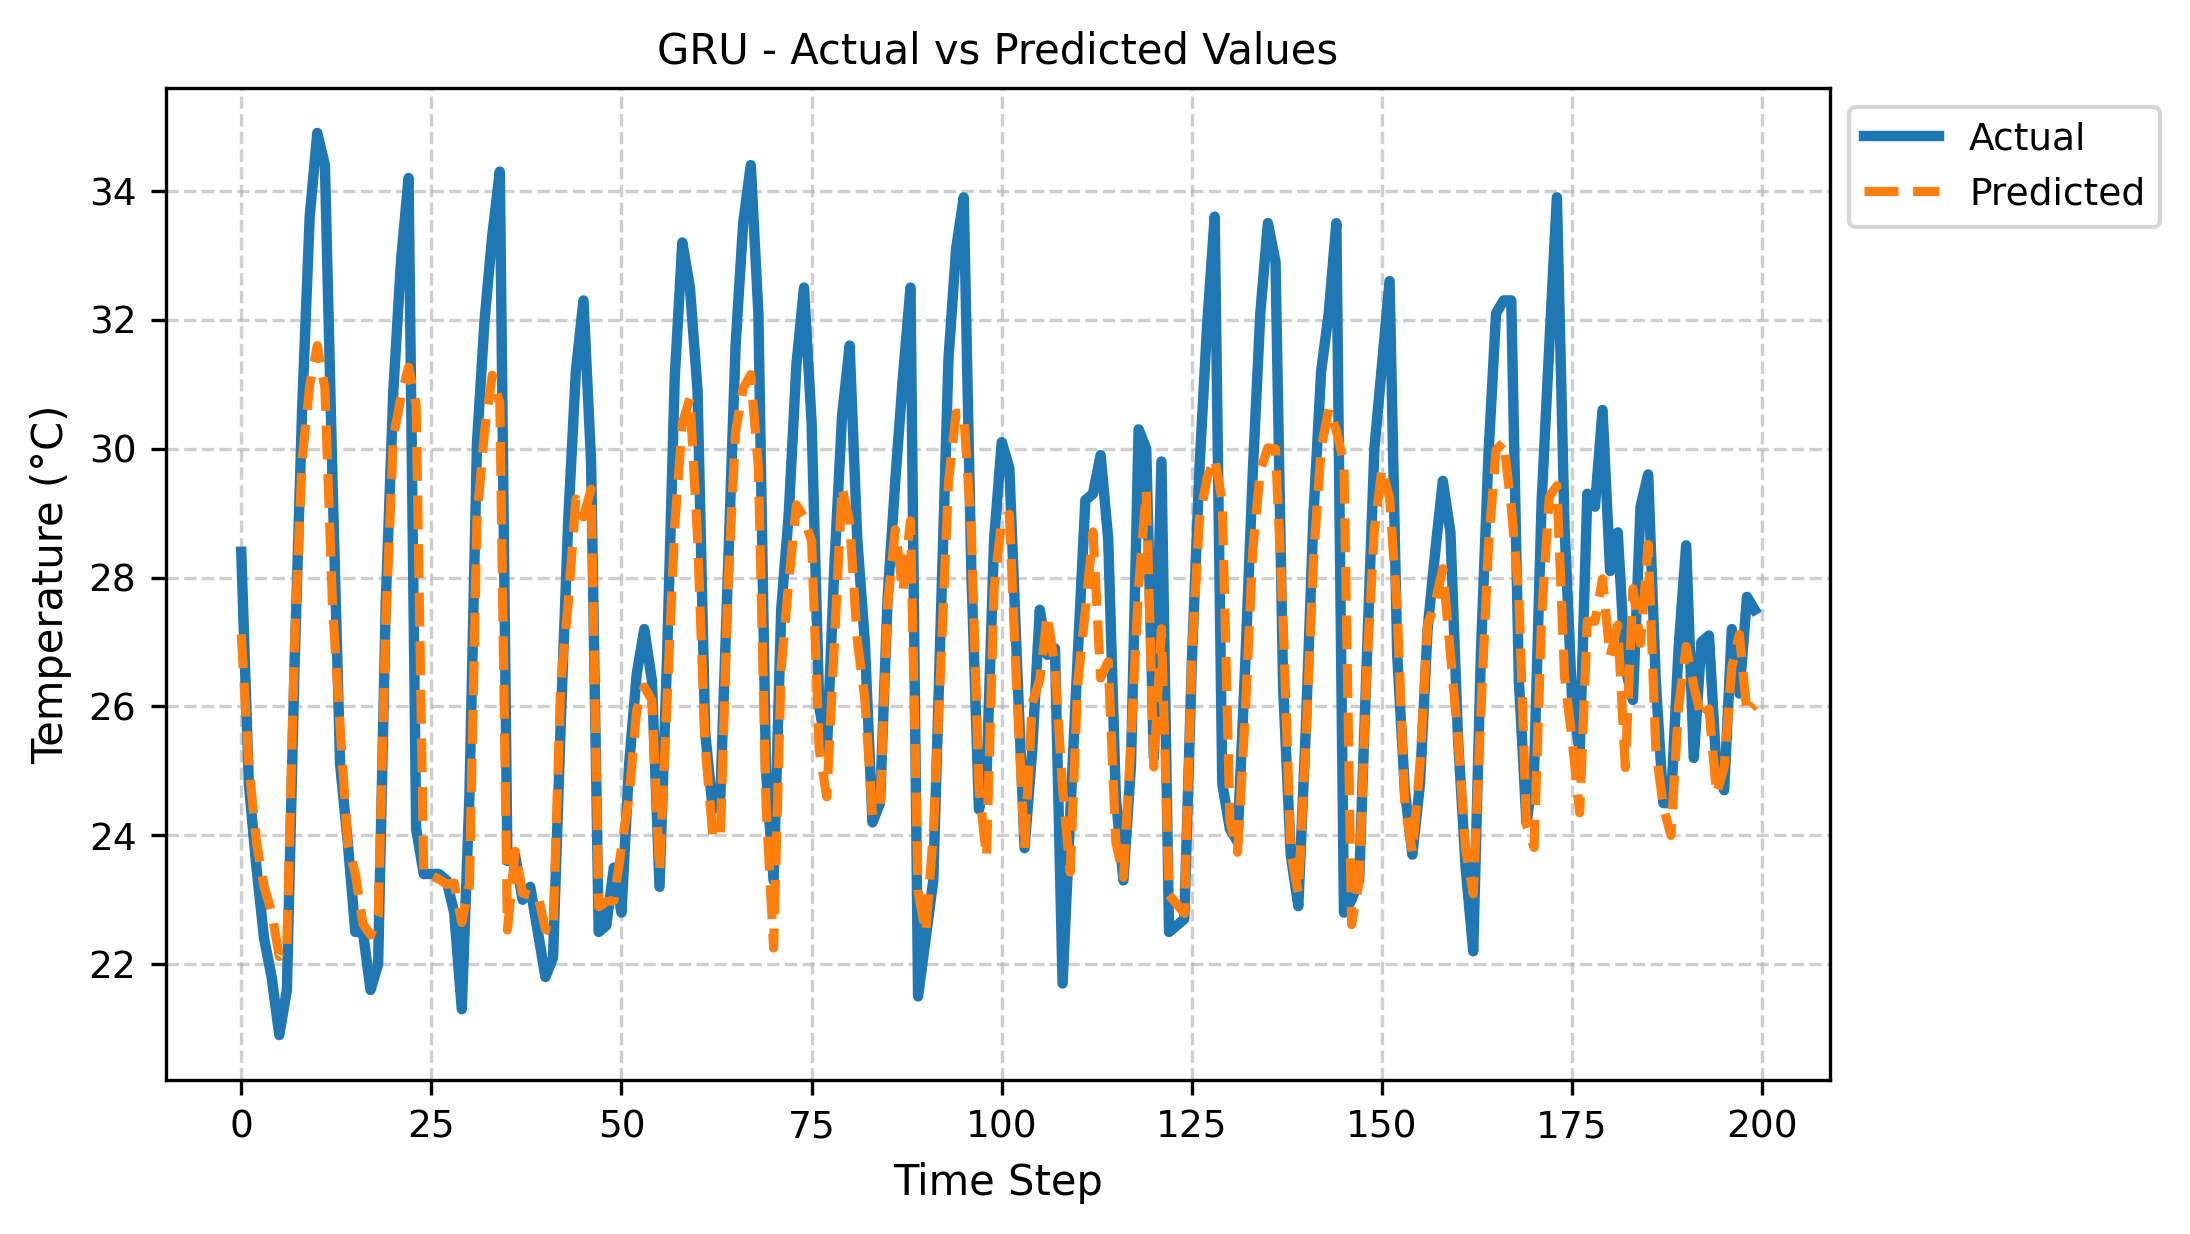

In [14]:

# LOAD GRU MODEL + HISTORY

model_gru = load_model("models/gru_temperature_model_final.keras")
history_gru = joblib.load("history/gru_history.pkl")


# PREDICT

y_pred_gru = model_gru.predict(X_test_seq)

y_pred_gru_actual = scaler_y.inverse_transform(y_pred_gru)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# PLOT

plot_loss(history_gru, "GRU")

plot_actual_vs_predicted(
    y_test_actual,
    y_pred_gru_actual,
    "GRU"
)

In [30]:
#Bi-LSTM
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

model_bilstm_final = Sequential()

model_bilstm_final.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# BLOCK 1
model_bilstm_final.add(Bidirectional(LSTM(96, return_sequences=True)))
model_bilstm_final.add(BatchNormalization())
model_bilstm_final.add(Dropout(0.30))

# BLOCK 2
model_bilstm_final.add(Bidirectional(LSTM(48, return_sequences=True)))
model_bilstm_final.add(BatchNormalization())
model_bilstm_final.add(Dropout(0.30))

# BLOCK 3
model_bilstm_final.add(Bidirectional(LSTM(32)))
model_bilstm_final.add(Dropout(0.25))

# DENSE
model_bilstm_final.add(Dense(64, activation='relu'))
model_bilstm_final.add(Dropout(0.2))
model_bilstm_final.add(Dense(32, activation='relu'))
model_bilstm_final.add(Dense(16, activation='relu'))
model_bilstm_final.add(Dense(1))



#Compile
optimizer = Adam(learning_rate=0.0005)

model_bilstm_final.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)
#Call backs
#Early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)
#Reduce lr
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)
#Checkpoint
checkpoint = ModelCheckpoint(
    "models/best_bilstm_weather_model.keras",
    monitor='val_loss',
    save_best_only=True
)
#Training
history_bilstm = model_bilstm_final.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,        # Updated to project standard
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=2
)
#Prediction
y_pred_bilstm = model_bilstm_final.predict(X_test_seq)

y_pred_bilstm_actual = scaler_y.inverse_transform(y_pred_bilstm)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

#Evaluation
metrics_bilstm = evaluate_regression_metrics(
    y_test_actual,
    y_pred_bilstm_actual
)

#Save model
model_bilstm_final.save(
    "models/bilstm_temperature_model_final.keras"
)

#Save metrics
with open("metrics/bilstm_metrics.json", "w") as f:
    json.dump(metrics_bilstm, f, indent=4)
#Save History
joblib.dump(
    history_bilstm.history,
    "history/bilstm_history.pkl"
)

Epoch 1/50
5791/5791 - 617s - 106ms/step - loss: 0.0029 - mae: 0.0348 - val_loss: 0.0018 - val_mae: 0.0347 - learning_rate: 5.0000e-04
Epoch 2/50
5791/5791 - 579s - 100ms/step - loss: 7.4957e-04 - mae: 0.0196 - val_loss: 0.0010 - val_mae: 0.0233 - learning_rate: 5.0000e-04
Epoch 3/50
5791/5791 - 585s - 101ms/step - loss: 6.3031e-04 - mae: 0.0176 - val_loss: 0.0013 - val_mae: 0.0276 - learning_rate: 5.0000e-04
Epoch 4/50
5791/5791 - 596s - 103ms/step - loss: 5.7802e-04 - mae: 0.0167 - val_loss: 9.6757e-04 - val_mae: 0.0228 - learning_rate: 5.0000e-04
Epoch 5/50
5791/5791 - 591s - 102ms/step - loss: 5.5188e-04 - mae: 0.0162 - val_loss: 8.8744e-04 - val_mae: 0.0223 - learning_rate: 5.0000e-04
Epoch 6/50
5791/5791 - 614s - 106ms/step - loss: 5.3353e-04 - mae: 0.0158 - val_loss: 7.7138e-04 - val_mae: 0.0207 - learning_rate: 5.0000e-04
Epoch 7/50
5791/5791 - 596s - 103ms/step - loss: 5.1893e-04 - mae: 0.0155 - val_loss: 8.3857e-04 - val_mae: 0.0212 - learning_rate: 5.0000e-04
Epoch 8/50
5791

['history/bilstm_history.pkl']

In [22]:

# LOAD MODEL

model_bilstm = load_model("models/bilstm_temperature_model_final.keras")
print(" BiLSTM Model Loaded Successfully")

print("\n Model Summary:")
model_bilstm.summary()

# LOAD HISTORY

history_bilstm = joblib.load("history/bilstm_history.pkl")
print("\n BiLSTM History Loaded Successfully")

print("\n History Keys:")
print(history_bilstm.keys())


# LOAD METRICS

with open("metrics/bilstm_metrics.json") as f:
    metrics_bilstm = json.load(f)

print("\n BiLSTM Metrics Loaded Successfully")

print("\n Metrics Values:")
for k, v in metrics_bilstm.items():
    print(f"{k} : {v}")

 BiLSTM Model Loaded Successfully

 Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 24, 192)             │          86,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 192)             │             768 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 24, 192)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 24, 96)              │          92,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 96)              │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 24, 96)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 659,717 (2.52 MB)

 Trainable params: 219,713 (858.25 KB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 439,428 (1.68 MB)


 BiLSTM History Loaded Successfully

 History Keys:
dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

 BiLSTM Metrics Loaded Successfully

 Metrics Values:
MSE : 1.6750939761131498
MAE : 0.9666616792570117
RMSE : 1.2942542161851935
MAPE : 4.19037570050484
R2 : 0.9307538278038284


5790/5790 ━━━━━━━━━━━━━━━━━━━━ 78s 13ms/step


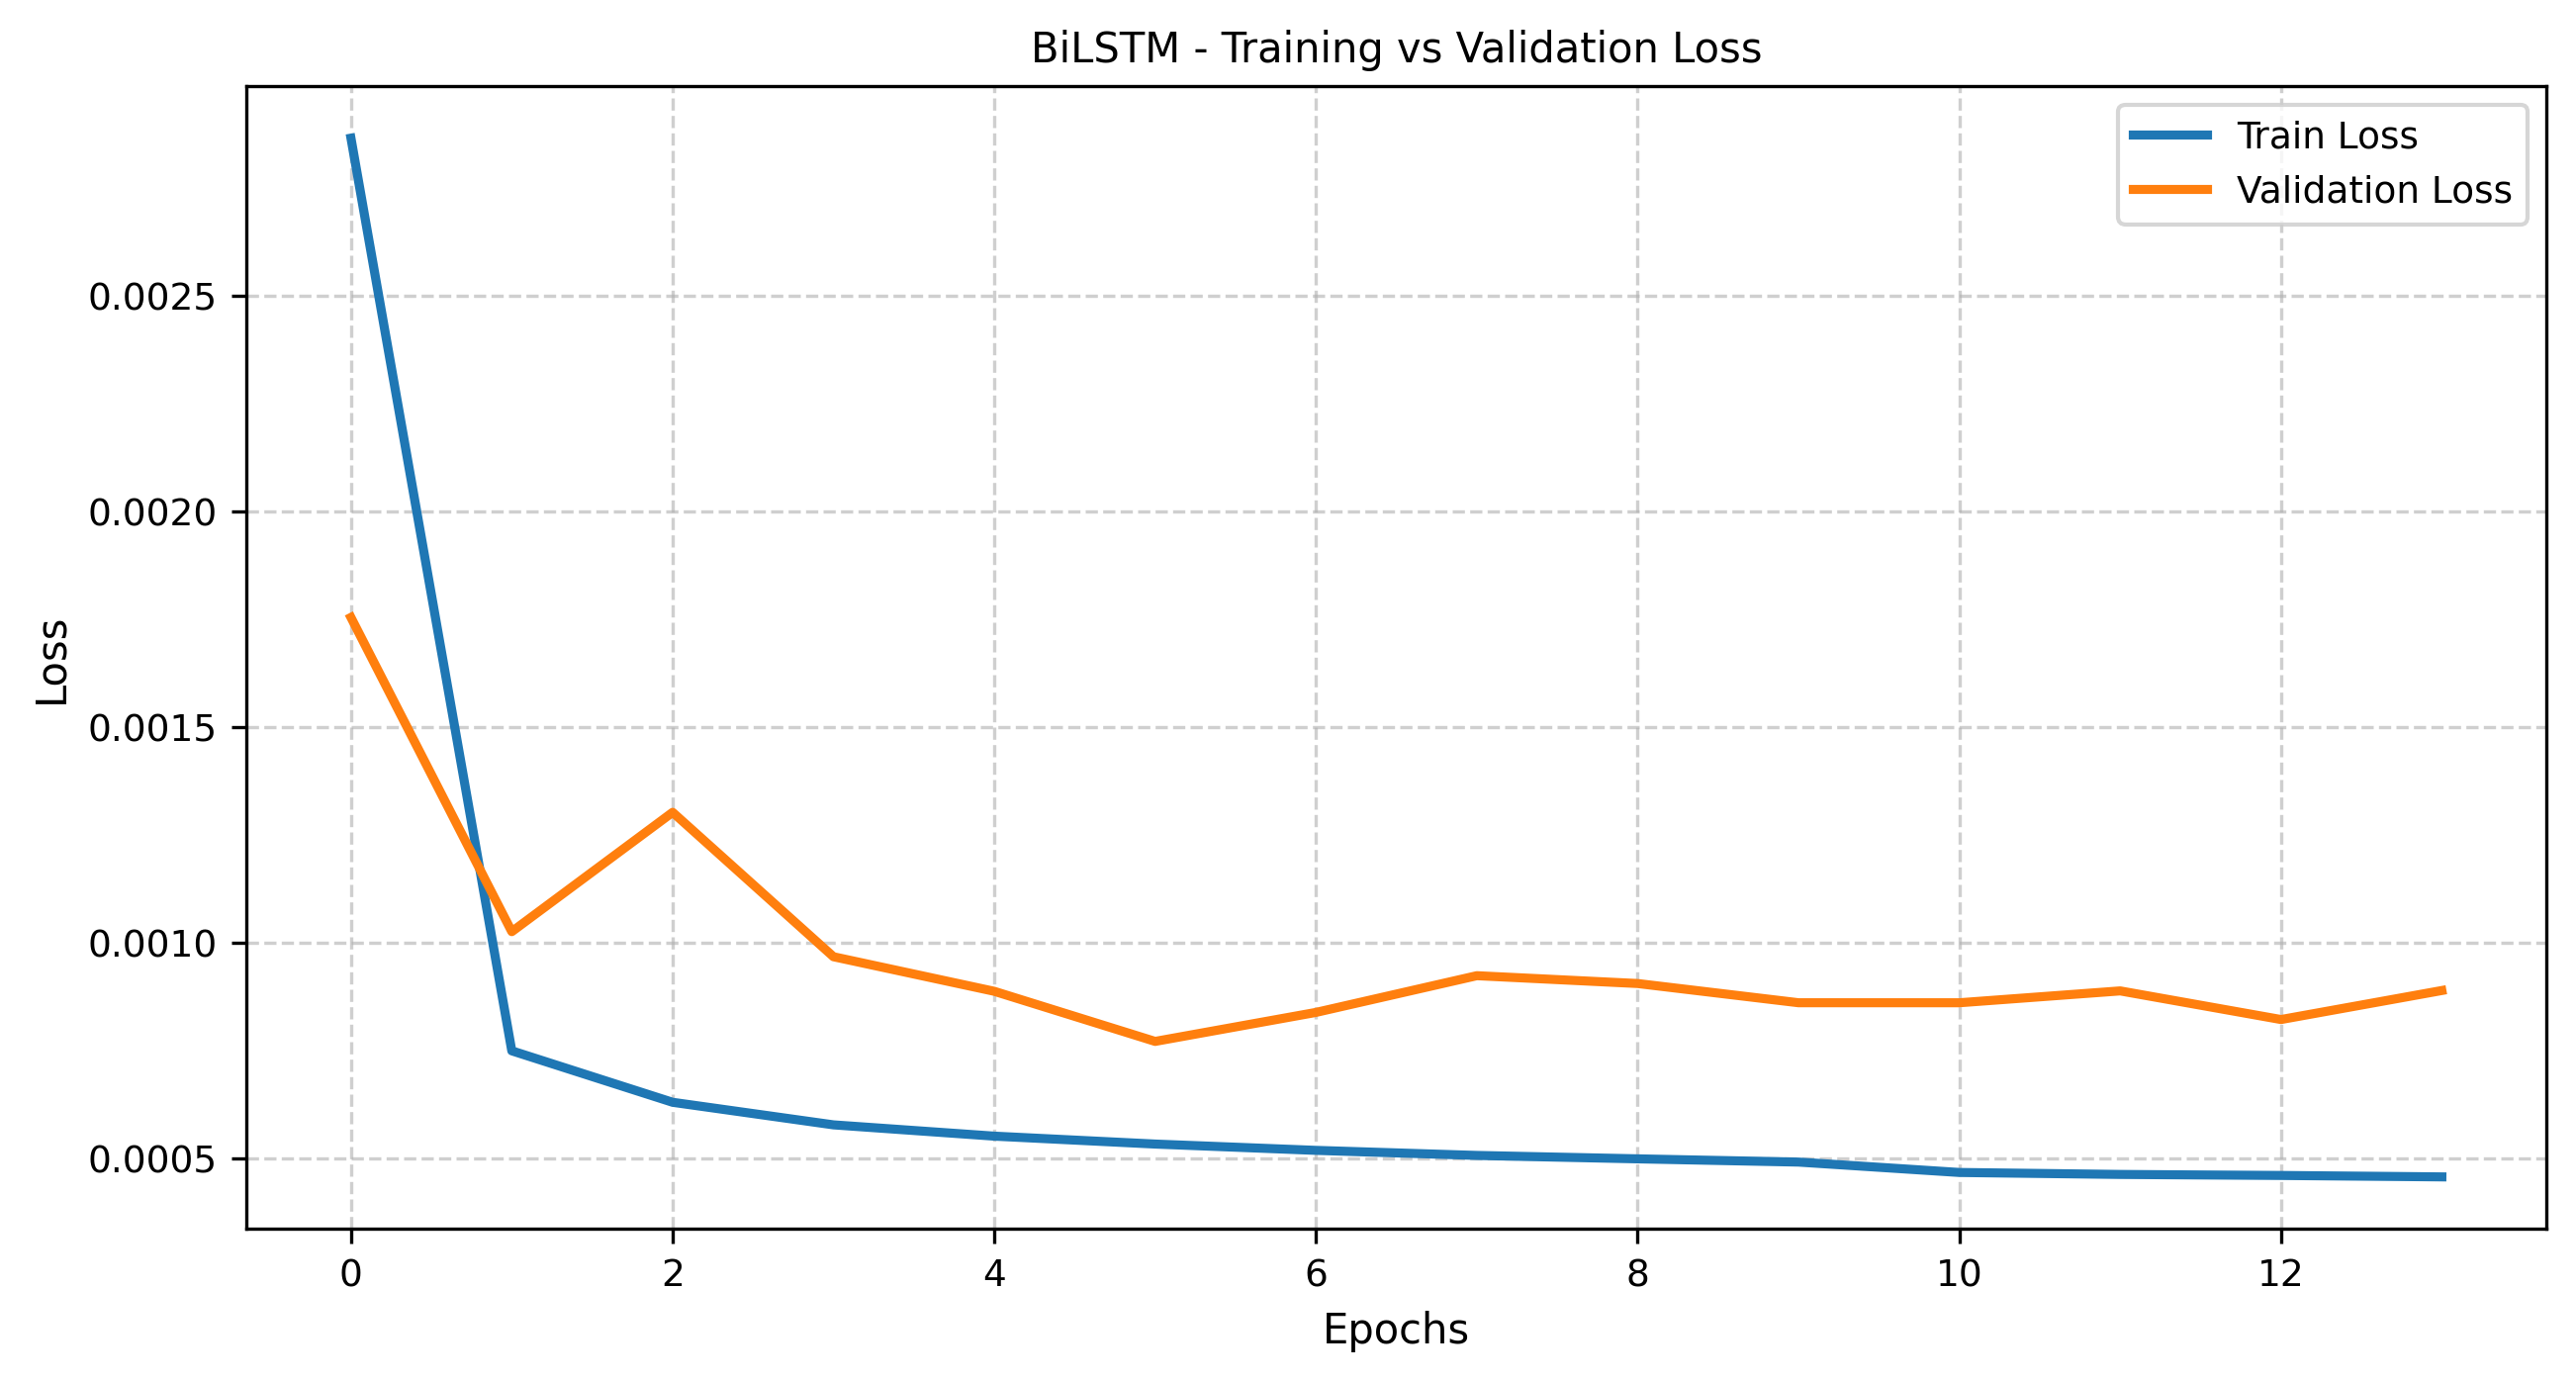

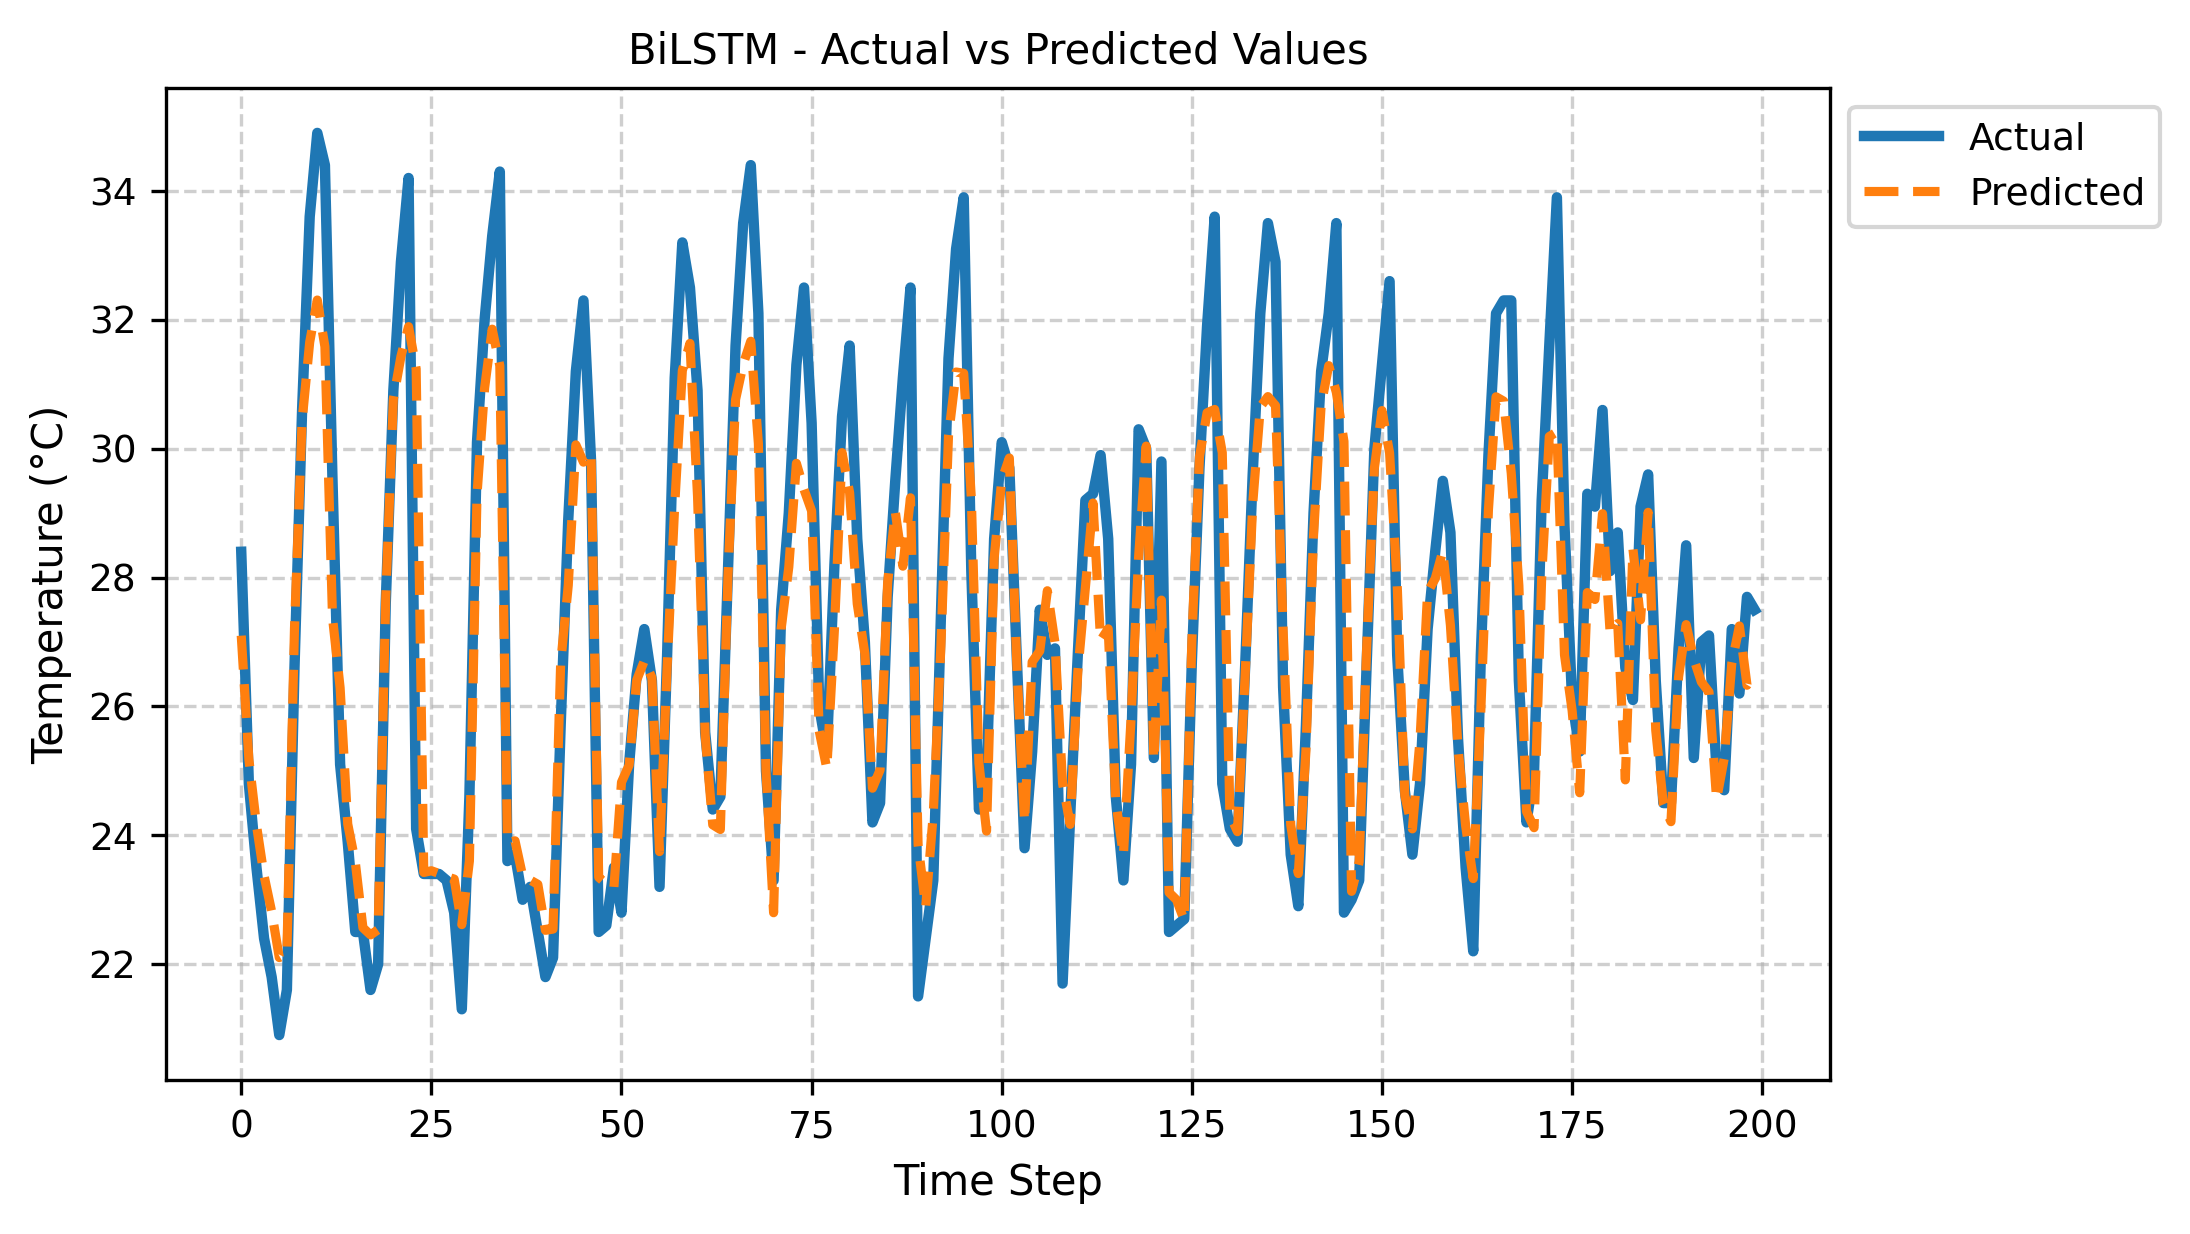

In [16]:

# LOAD BiLSTM

model_bilstm = load_model("models/bilstm_temperature_model_final.keras")
history_bilstm = joblib.load("history/bilstm_history.pkl")


# PREDICT

y_pred_bilstm = model_bilstm.predict(X_test_seq)

y_pred_bilstm_actual = scaler_y.inverse_transform(y_pred_bilstm)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# PLOT

plot_loss(history_bilstm, "BiLSTM")

plot_actual_vs_predicted(
    y_test_actual,
    y_pred_bilstm_actual,
    "BiLSTM"
)

In [28]:
class AttentionLayer(Layer):

    def __init__(self, **kwargs):   
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )

        self.V = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs):

        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(
            tf.matmul(score, self.V),
            axis=1
        )

        context = inputs * attention_weights
        return tf.reduce_sum(context, axis=1)

    def get_config(self):
        config = super().get_config()
        return config

In [ ]:

# BiLSTM +  ADDITIVE ATTENTION MODEL


np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

model_bilstm_att = Sequential()

model_bilstm_att.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# BLOCK 1
model_bilstm_att.add(Bidirectional(LSTM(128, return_sequences=True)))
model_bilstm_att.add(BatchNormalization())
model_bilstm_att.add(Dropout(0.25))

# BLOCK 2
model_bilstm_att.add(Bidirectional(LSTM(64, return_sequences=True)))
model_bilstm_att.add(BatchNormalization())
model_bilstm_att.add(Dropout(0.25))

# ATTENTION BLOCK 
model_bilstm_att.add(AttentionLayer())

# DENSE
model_bilstm_att.add(Dense(64, activation='relu'))
model_bilstm_att.add(Dropout(0.2))
model_bilstm_att.add(Dense(32, activation='relu'))
model_bilstm_att.add(Dense(16, activation='relu'))
model_bilstm_att.add(Dense(1))

# ======================
# COMPILE
# ======================
optimizer = Adam(learning_rate=0.0005)

model_bilstm_att.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "models/best_bilstm_attention_weather_model.keras",
    monitor='val_loss',
    save_best_only=True
)


# TRAINING

history_bilstm_att = model_bilstm_att.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=2
)


# PREDICTION

y_pred_bilstm_att = model_bilstm_att.predict(X_test_seq)

y_pred_bilstm_att_actual = scaler_y.inverse_transform(y_pred_bilstm_att)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# EVALUATION

metrics_bilstm_att = evaluate_regression_metrics(
    y_test_actual,
    y_pred_bilstm_att_actual
)


# SAVE MODEL

model_bilstm_att.save(
    "models/bilstm_attention_temperature_model.keras"
)


# SAVE METRICS

with open("metrics/bilstm_attention_metrics.json", "w") as f:
    json.dump(metrics_bilstm_att, f, indent=4)


# SAVE HISTORY

joblib.dump(
    history_bilstm_att.history,
    "history/bilstm_attention_history.pkl"
)


In [29]:

# LOAD MODEL

model_bilstm_att_loaded = load_model(
    "models/bilstm_attention_temperature_model.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)

print(" BiLSTM + Attention Model Loaded Successfully")
print("\n Model Summary:")
model_bilstm_att_loaded.summary()


# LOAD HISTORY

history_bilstm_att_loaded = joblib.load(
    "history/bilstm_attention_history.pkl"
)

print("\n BiLSTM + Attention History Loaded Successfully")

print("\n History Keys:")
print(history_bilstm_att_loaded.keys())


# LOAD METRICS

with open("metrics/bilstm_attention_metrics.json") as f:
    metrics_bilstm_att_loaded = json.load(f)

print("\n BiLSTM + Attention Metrics Loaded Successfully")

print("\n Metrics Values:")
for k, v in metrics_bilstm_att_loaded.items():
    print(f"{k} : {v}")



 BiLSTM + Attention Model Loaded Successfully

 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 24, 256)             │         148,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 24, 128)             │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (AttentionLayer)     │ (None, 128)                 │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,024,133 (3.91 MB)

 Trainable params: 341,121 (1.30 MB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 682,244 (2.60 MB)


 BiLSTM + Attention History Loaded Successfully

 History Keys:
dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

 BiLSTM + Attention Metrics Loaded Successfully

 Metrics Values:
MSE : 1.963179388370476
MAE : 1.059247784441715
RMSE : 1.4011350357372683
MAPE : 4.530985472121725
R2 : 0.9188447574180196


5790/5790 ━━━━━━━━━━━━━━━━━━━━ 85s 15ms/step


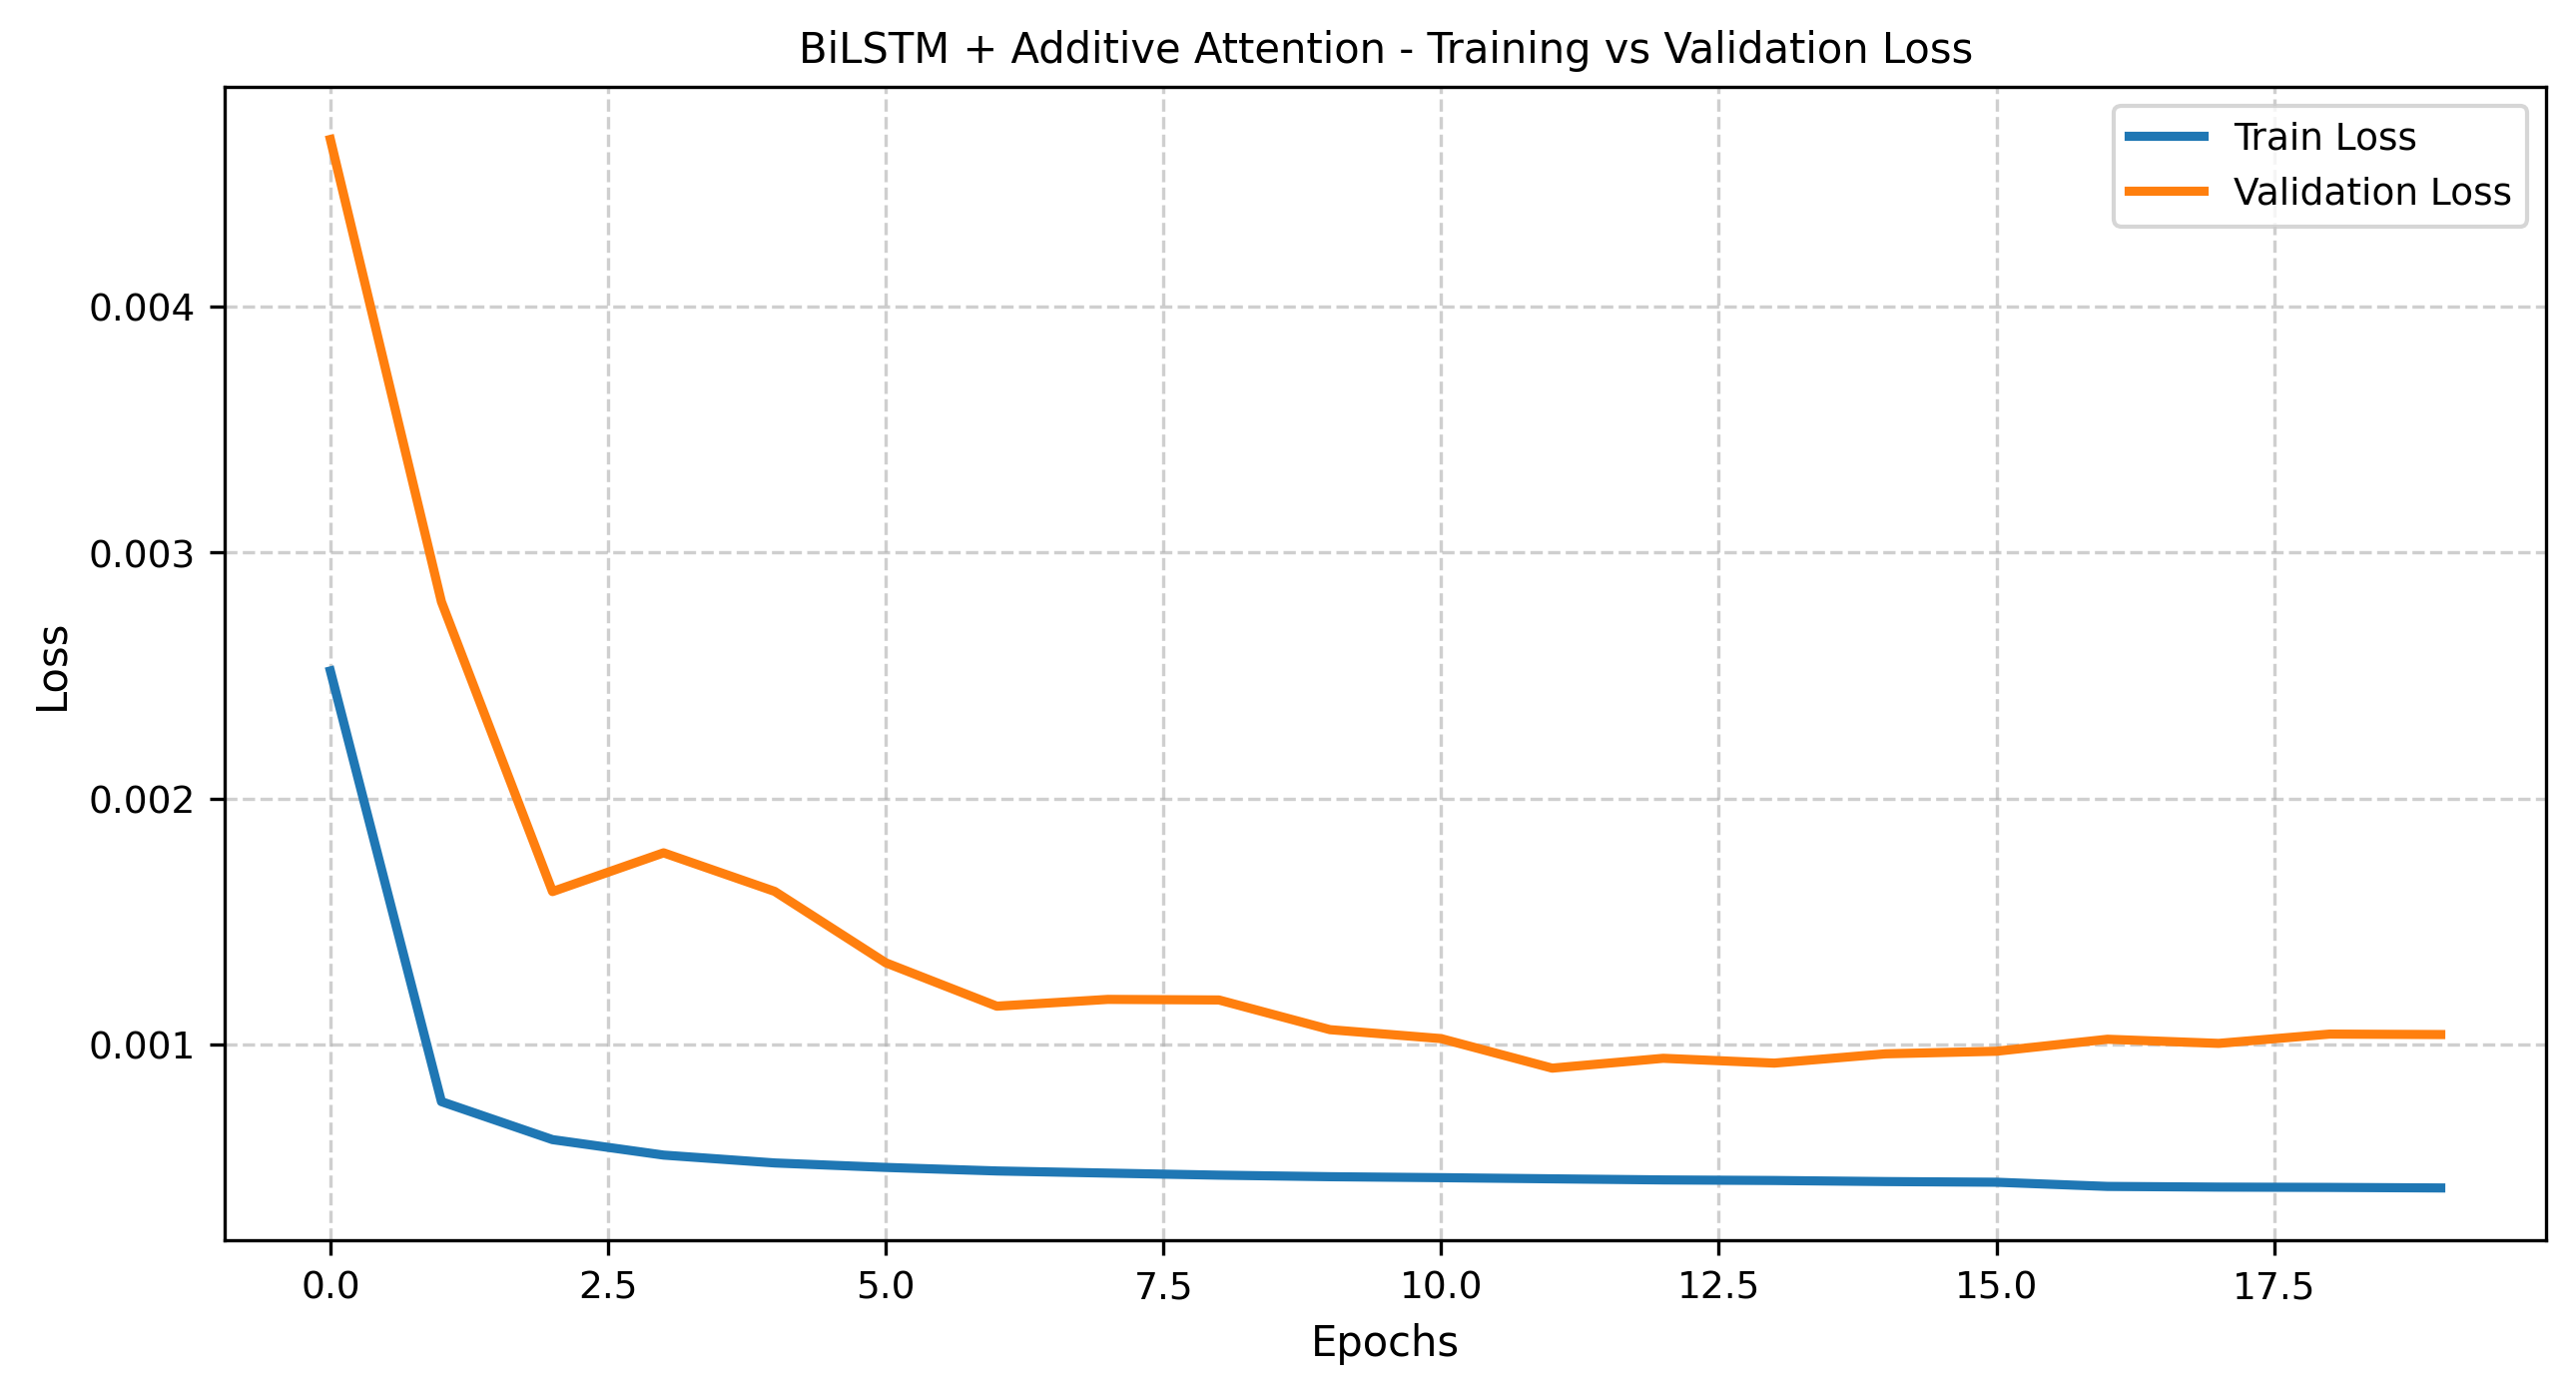

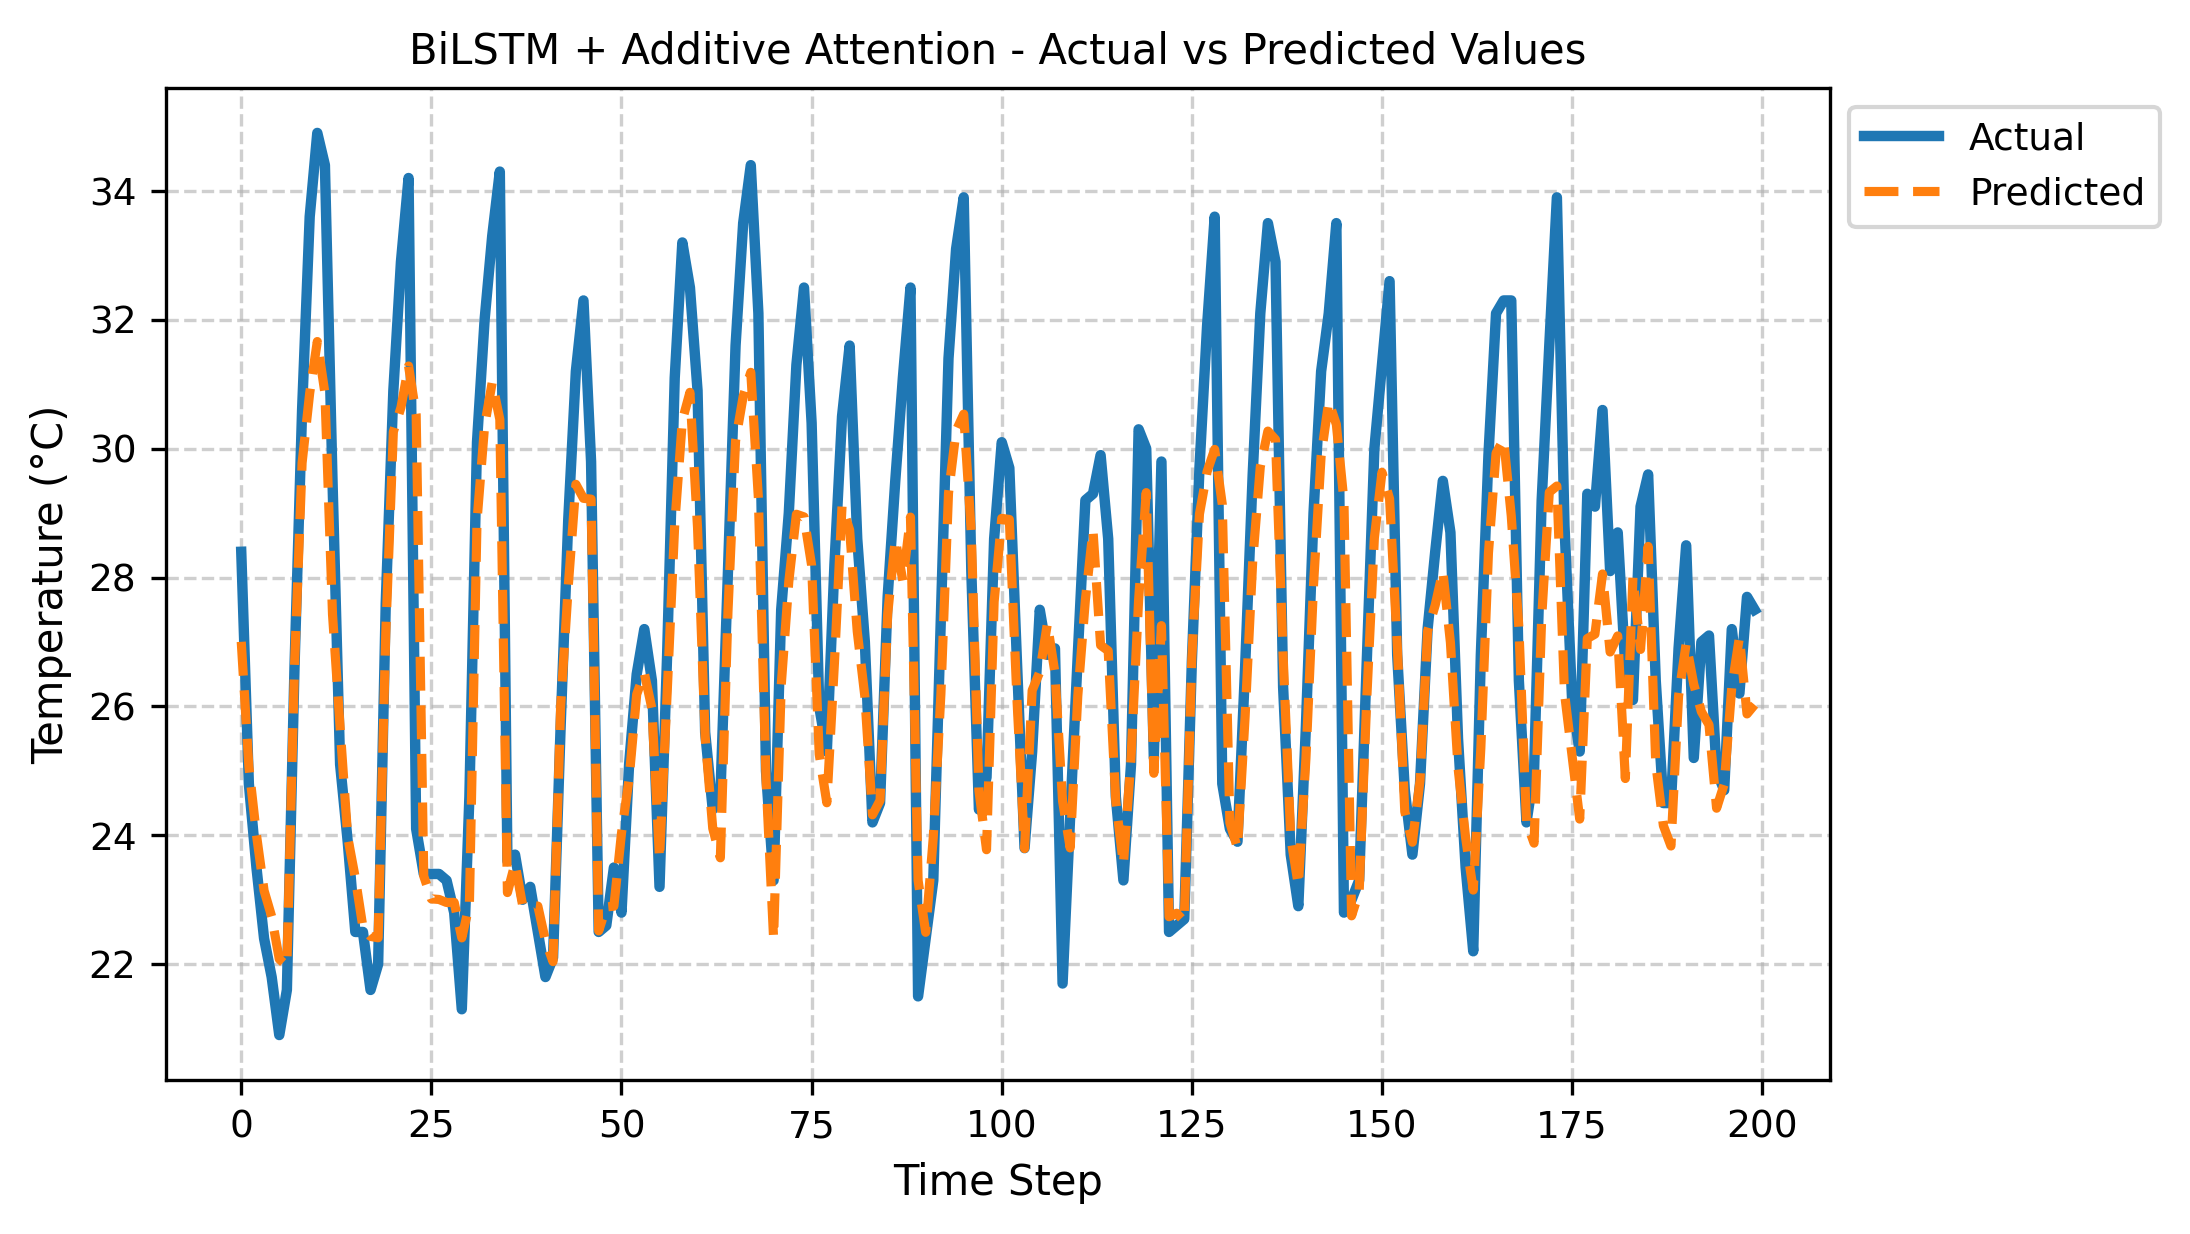

In [19]:

# LOAD MODEL (CUSTOM LAYER)

model_bilstm_att = load_model(
    "models/bilstm_attention_temperature_model.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)

history_bilstm_att = joblib.load("history/bilstm_attention_history.pkl")


# PREDICT

y_pred_bilstm_att = model_bilstm_att.predict(X_test_seq)

y_pred_bilstm_att_actual = scaler_y.inverse_transform(y_pred_bilstm_att)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# PLOT

plot_loss(history_bilstm_att, "BiLSTM + Additive Attention")

plot_actual_vs_predicted(
    y_test_actual,
    y_pred_bilstm_att_actual,
    "BiLSTM + Additive Attention"
)

In [31]:
class TemporalAttentionLayerV2(Layer):

    def __init__(self, **kwargs):   
        super(TemporalAttentionLayerV2, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="temp_att_weight_v2",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform"
        )

        self.b = self.add_weight(
            name="temp_att_bias_v2",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

    def get_config(self):   
        config = super().get_config()
        return config


In [19]:

# BiLSTM + TEMPORAL ATTENTION MODEL 

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

model_bilstm_temp_att = Sequential()

model_bilstm_temp_att.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

# BLOCK 1
model_bilstm_temp_att.add(Bidirectional(LSTM(128, return_sequences=True)))
model_bilstm_temp_att.add(BatchNormalization())
model_bilstm_temp_att.add(Dropout(0.25))

# BLOCK 2
model_bilstm_temp_att.add(Bidirectional(LSTM(64, return_sequences=True)))
model_bilstm_temp_att.add(BatchNormalization())
model_bilstm_temp_att.add(Dropout(0.25))

# TEMPORAL ATTENTION BLOCK (NEW)
model_bilstm_temp_att.add(TemporalAttentionLayerV2())

# DENSE
model_bilstm_temp_att.add(Dense(64, activation='relu'))
model_bilstm_temp_att.add(Dropout(0.2))
model_bilstm_temp_att.add(Dense(32, activation='relu'))
model_bilstm_temp_att.add(Dense(16, activation='relu'))
model_bilstm_temp_att.add(Dense(1))


# COMPILE

optimizer_temp_att = Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model_bilstm_temp_att.compile(
    optimizer=optimizer_temp_att,
    loss=Huber(delta=1.0),
    metrics=['mae']
)


# CALLBACKS

early_stop_temp_att = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_temp_att = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

checkpoint_temp_att = ModelCheckpoint(
    "models/best_bilstm_temporal_attention_weather_model.keras",
    monitor='val_loss',
    save_best_only=True
)


# TRAINING

history_bilstm_temp_att = model_bilstm_temp_att.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop_temp_att, reduce_lr_temp_att, checkpoint_temp_att],
    verbose=2
)


# PREDICTION

y_pred_bilstm_temp_att = model_bilstm_temp_att.predict(X_test_seq)

y_pred_bilstm_temp_att_actual = scaler_y.inverse_transform(y_pred_bilstm_temp_att)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# EVALUATION

metrics_bilstm_temp_att = evaluate_regression_metrics(
    y_test_actual,
    y_pred_bilstm_temp_att_actual
)


# SAVE MODEL

model_bilstm_temp_att.save(
    "models/bilstm_temporal_attention_temperature_model.keras"
)


# SAVE METRICS

with open("metrics/bilstm_temporal_attention_metrics.json", "w") as f:
    json.dump(metrics_bilstm_temp_att, f, indent=4)


# SAVE HISTORY

joblib.dump(
    history_bilstm_temp_att.history,
    "history/bilstm_temporal_attention_history.pkl"
)



Epoch 1/50
5791/5791 - 705s - 122ms/step - loss: 0.0014 - mae: 0.0335 - val_loss: 9.9402e-04 - val_mae: 0.0338 - learning_rate: 5.0000e-04
Epoch 2/50
5791/5791 - 633s - 109ms/step - loss: 3.7431e-04 - mae: 0.0196 - val_loss: 6.9571e-04 - val_mae: 0.0283 - learning_rate: 5.0000e-04
Epoch 3/50
5791/5791 - 621s - 107ms/step - loss: 3.1476e-04 - mae: 0.0176 - val_loss: 6.1754e-04 - val_mae: 0.0265 - learning_rate: 5.0000e-04
Epoch 4/50
5791/5791 - 623s - 108ms/step - loss: 2.8740e-04 - mae: 0.0165 - val_loss: 5.8882e-04 - val_mae: 0.0262 - learning_rate: 5.0000e-04
Epoch 5/50
5791/5791 - 618s - 107ms/step - loss: 2.7004e-04 - mae: 0.0159 - val_loss: 5.2964e-04 - val_mae: 0.0246 - learning_rate: 5.0000e-04
Epoch 6/50
5791/5791 - 614s - 106ms/step - loss: 2.5733e-04 - mae: 0.0154 - val_loss: 5.3158e-04 - val_mae: 0.0254 - learning_rate: 5.0000e-04
Epoch 7/50
5791/5791 - 619s - 107ms/step - loss: 2.4879e-04 - mae: 0.0150 - val_loss: 4.7628e-04 - val_mae: 0.0231 - learning_rate: 5.0000e-04
Ep

['history/bilstm_temporal_attention_history.pkl']

In [32]:

# LOAD TEMPORAL ATTENTION MODEL


model_bilstm_temp_att_loaded = load_model(
    "models/bilstm_temporal_attention_temperature_model.keras",
    custom_objects={"TemporalAttentionLayerV2": TemporalAttentionLayerV2}
)

print(" BiLSTM + Temporal Attention Model Loaded Successfully")

print("\n Model Summary:")
model_bilstm_temp_att_loaded.summary()


# LOAD HISTORY

history_bilstm_temp_att_loaded = joblib.load(
    "history/bilstm_temporal_attention_history.pkl"
)

print("\n BiLSTM + Temporal Attention History Loaded Successfully")

print("\n History Keys:")
print(history_bilstm_temp_att_loaded.keys())


# LOAD METRICS

with open("metrics/bilstm_temporal_attention_metrics.json") as f:
    metrics_bilstm_temp_att_loaded = json.load(f)

print("\n BiLSTM + Temporal Attention Metrics Loaded Successfully")

print("\n Metrics Values:")
for k, v in metrics_bilstm_temp_att_loaded.items():
    print(f"{k} : {v}")


 BiLSTM + Temporal Attention Model Loaded Successfully

 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 24, 256)             │         148,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 24, 128)             │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ temporal_attention_layer_v2          │ (None, 128)                 │             152 │
│ (TemporalAttentionLayerV2)           │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 974,669 (3.72 MB)

 Trainable params: 324,633 (1.24 MB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 649,268 (2.48 MB)


 BiLSTM + Temporal Attention History Loaded Successfully

 History Keys:
dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

 BiLSTM + Temporal Attention Metrics Loaded Successfully

 Metrics Values:
MSE : 1.7665432974452453
MAE : 0.9908267036672613
RMSE : 1.3291137263023225
MAPE : 4.156199095849771
R2 : 0.9269734336632686


5790/5790 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step


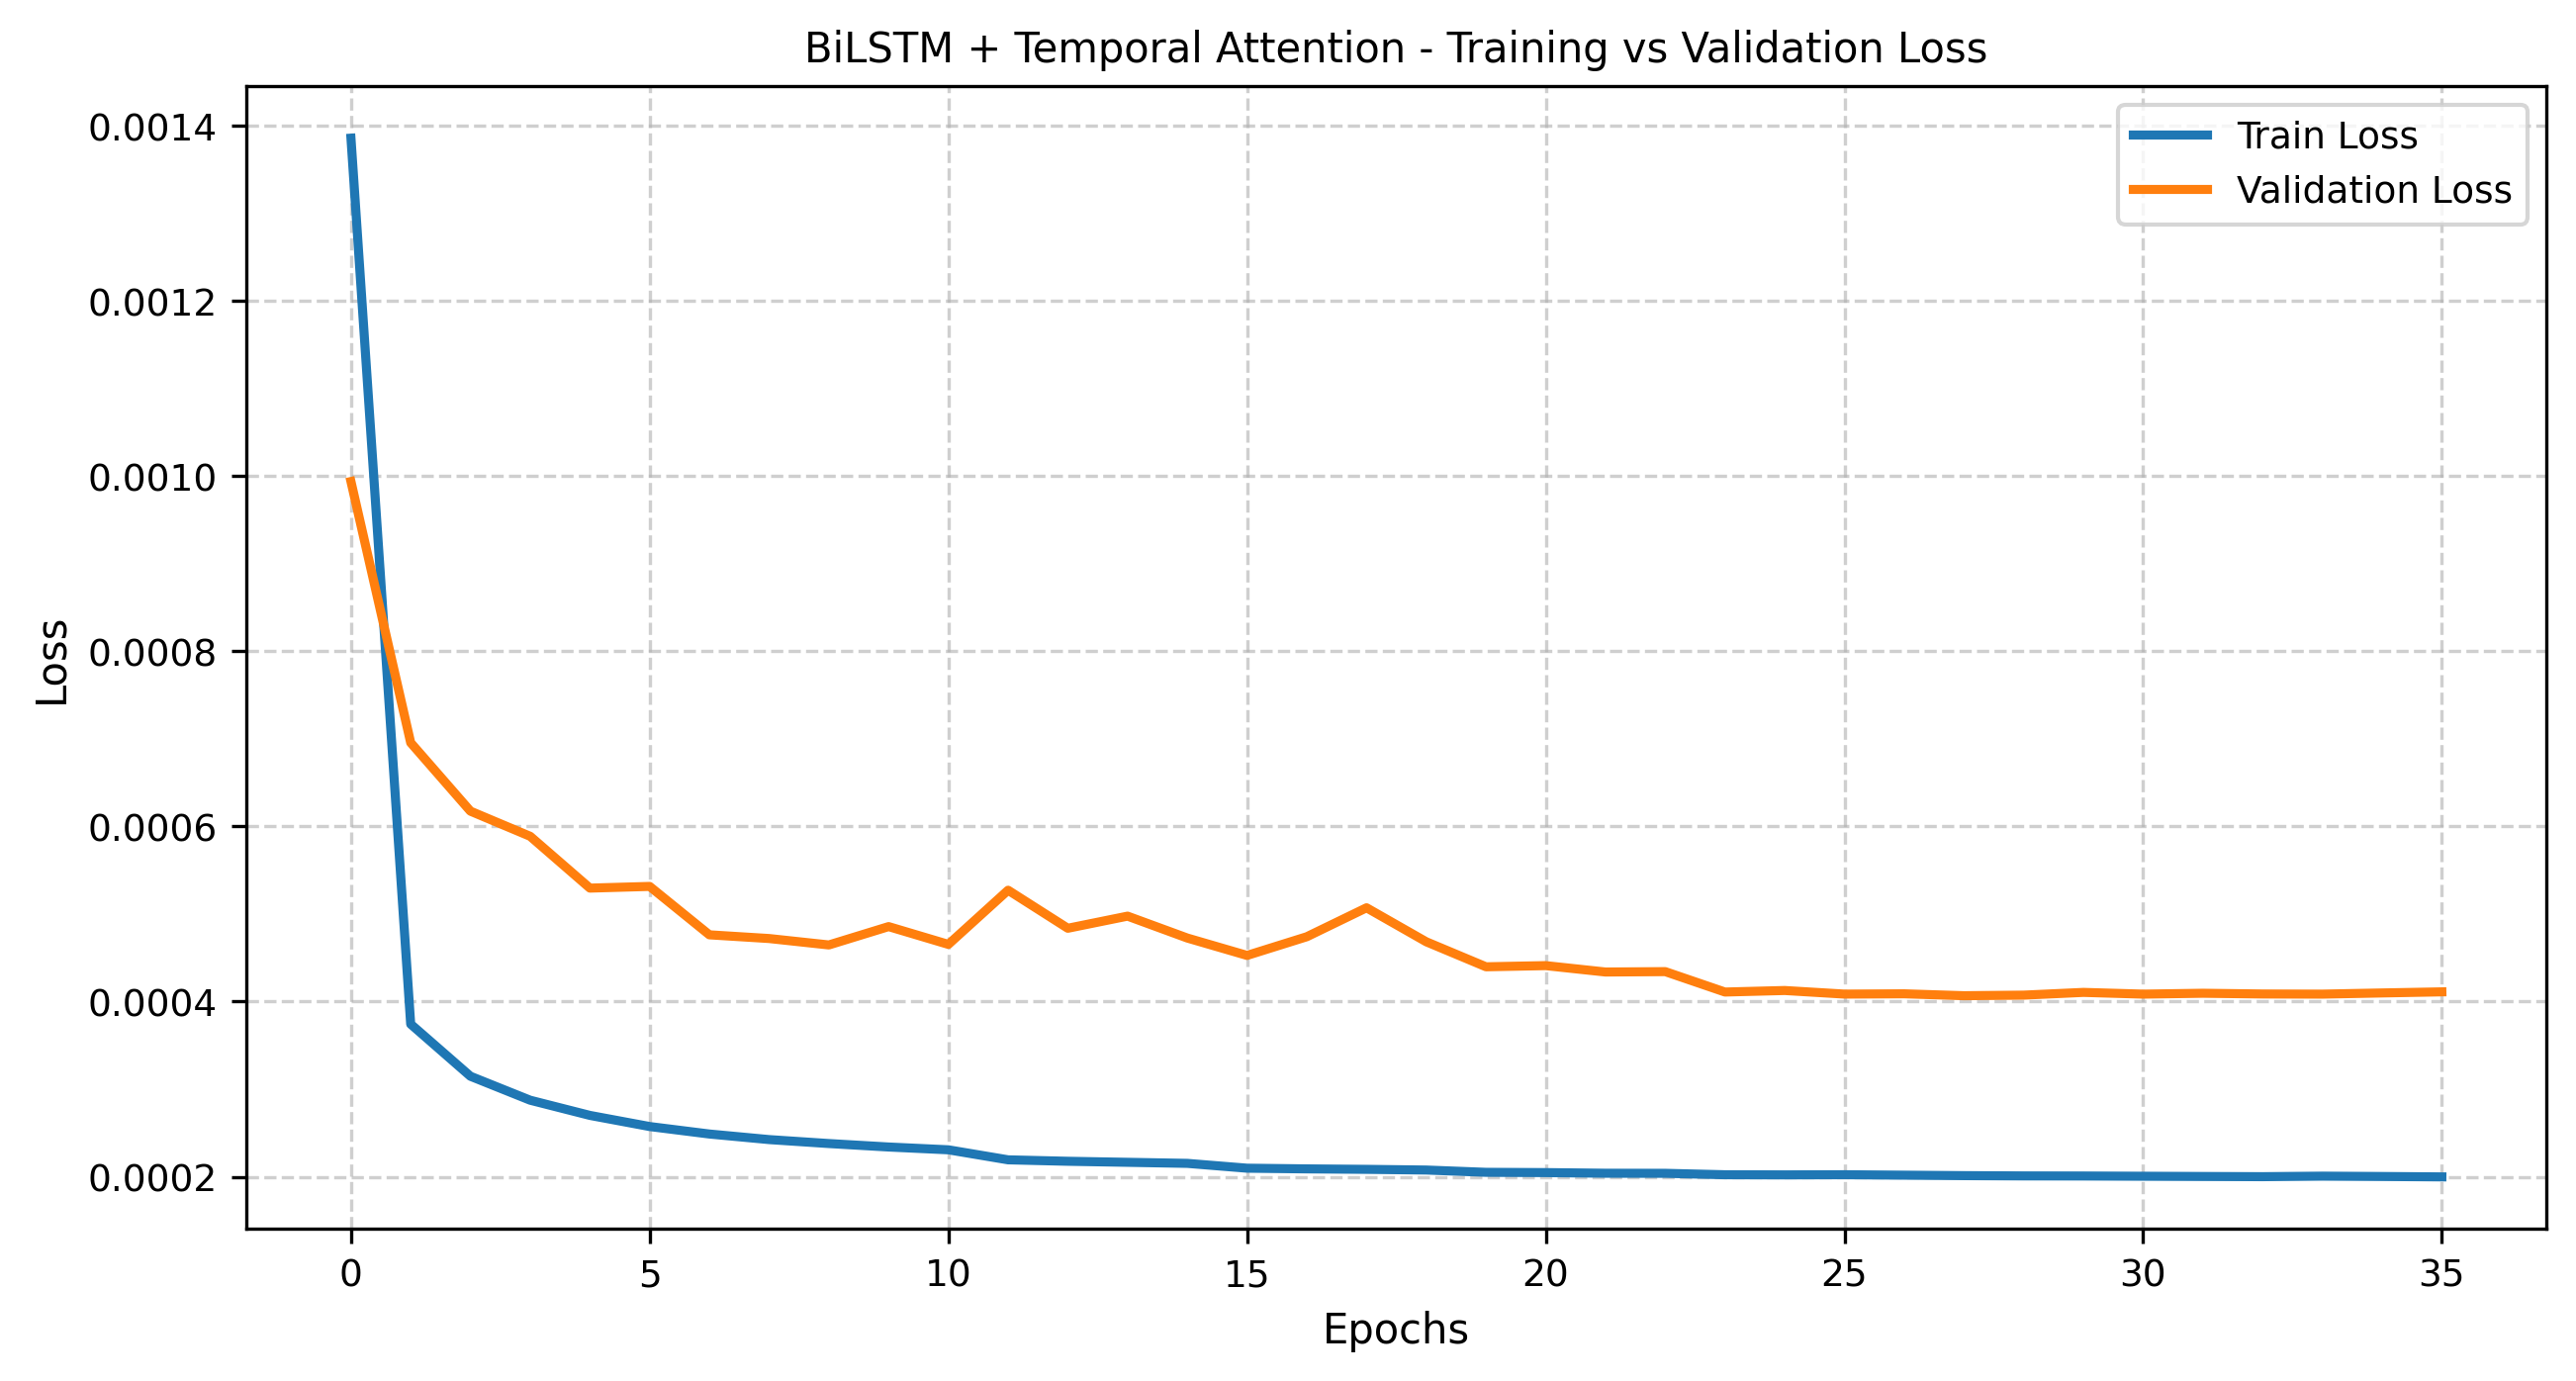

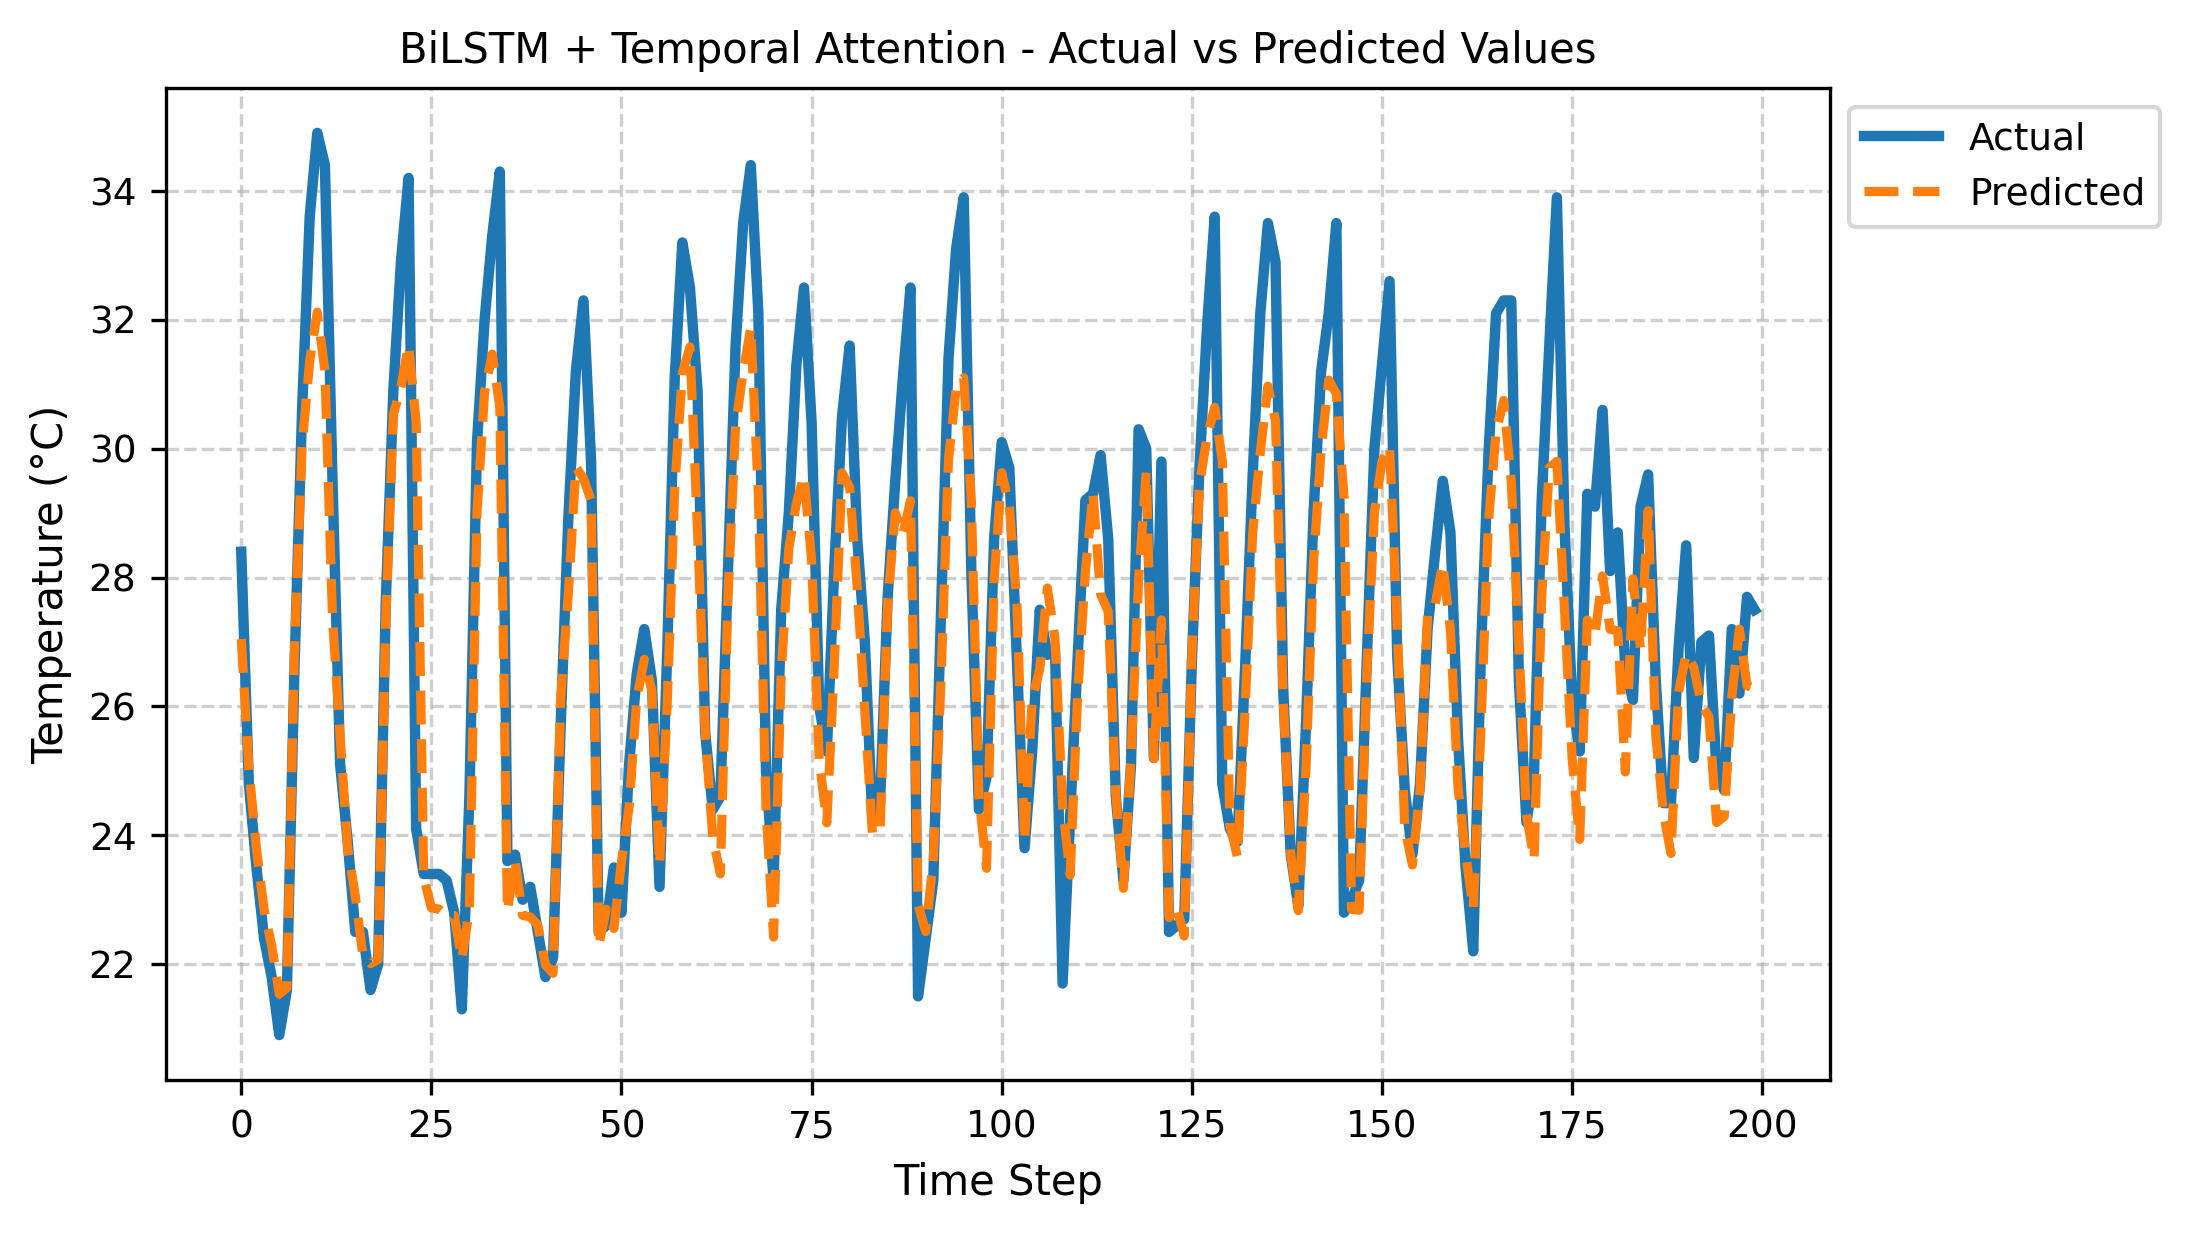

In [22]:

# LOAD MODEL (CUSTOM LAYER)

model_bilstm_temp_att = load_model(
    "models/bilstm_temporal_attention_temperature_model.keras",
    custom_objects={"TemporalAttentionLayerV2": TemporalAttentionLayerV2}
)

history_bilstm_temp_att = joblib.load("history/bilstm_temporal_attention_history.pkl")


# PREDICT

y_pred_bilstm_temp_att = model_bilstm_temp_att.predict(X_test_seq)

y_pred_bilstm_temp_att_actual = scaler_y.inverse_transform(y_pred_bilstm_temp_att)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# PLOT

plot_loss(history_bilstm_temp_att, "BiLSTM + Temporal Attention")

plot_actual_vs_predicted(
    y_test_actual,
    y_pred_bilstm_temp_att_actual,
    "BiLSTM + Temporal Attention"
)

In [34]:
def channel_se_block_v8(tensor_in, reduction_ratio=8):

    channels = int(tensor_in.shape[-1])

    se = tf.keras.layers.GlobalAveragePooling1D()(tensor_in)
    se = Dense(channels // reduction_ratio, activation="relu")(se)
    se = Dense(channels, activation="sigmoid")(se)

    se = Reshape((1, channels))(se)

    return tensor_in * se

In [35]:
class ResidualTemporalAttentionV8(Layer):

    def __init__(self, **kwargs):
        super(ResidualTemporalAttentionV8, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super().build(input_shape)

    def call(self, x):
        # Attention weights
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)

        # Context vector
        context = tf.reduce_sum(x * a, axis=1)

        # Residual (last timestep)
        last_state = x[:, -1, :]

        return context + last_state

In [36]:
def composite_loss_v8(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    huber = tf.keras.losses.Huber(delta=0.2)(y_true, y_pred)
    return 0.7 * mae + 0.3 * huber

In [25]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

input_seq_v8 = Input(
    shape=(X_train_seq.shape[1], X_train_seq.shape[2])
)

# MULTI-SCALE DILATED CNN


conv3 = Conv1D(32, 3, padding="same", dilation_rate=1,
               activation="relu")(input_seq_v8)
conv5 = Conv1D(32, 5, padding="same", dilation_rate=2,
               activation="relu")(input_seq_v8)
conv7 = Conv1D(32, 7, padding="same", dilation_rate=4,
               activation="relu")(input_seq_v8)

cnn = Concatenate()([conv3, conv5, conv7])
cnn = BatchNormalization()(cnn)

cnn = channel_se_block_v8(cnn)

cnn = Conv1D(64, 3, padding="same", activation="relu")(cnn)
cnn = BatchNormalization()(cnn)

# CNN Skip Connection
cnn_skip = Conv1D(64, 1, padding="same")(input_seq_v8)
cnn_out = Add()([cnn, cnn_skip])


# TEMPORAL MODELING


bilstm = Bidirectional(
    LSTM(128, return_sequences=True)
)(cnn_out)

bilstm = BatchNormalization()(bilstm)
bilstm = Dropout(0.15)(bilstm)


# RESIDUAL TEMPORAL ATTENTION


attn = ResidualTemporalAttentionV8()(bilstm)
attn = Dropout(0.1)(attn)

# DENSE HEAD


dense = Dense(64, activation="relu")(attn)
dense = Dense(32, activation="relu")(dense)

output_v8 = Dense(1)(dense)

model_cnn_bilstm_resatt_v8 = Model(input_seq_v8, output_v8)

optimizer_v8 = Adam(
    learning_rate=1e-4,
    clipnorm=1.0
)

model_cnn_bilstm_resatt_v8.compile(
    optimizer=optimizer_v8,
    loss=composite_loss_v8,
    metrics=["mae"]
)

early_stop_v8 = EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

reduce_lr_v8 = ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,
    patience=5,
    min_lr=5e-6
)

checkpoint_v8 = ModelCheckpoint(
    "models/best_cnn_bilstm_residual_attention_v8.keras",
    monitor="val_mae",
    save_best_only=True
)

history_cnn_bilstm_resatt_v8 = model_cnn_bilstm_resatt_v8.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=60,
    batch_size=128,
    callbacks=[early_stop_v8, reduce_lr_v8, checkpoint_v8],
    verbose=2
)

y_pred_v8 = model_cnn_bilstm_resatt_v8.predict(X_test_seq)

y_pred_v8_actual = scaler_y.inverse_transform(y_pred_v8)
y_test_actual_v8 = scaler_y.inverse_transform(y_test_seq)

metrics_cnn_bilstm_resatt_v8 = evaluate_regression_metrics(
    y_test_actual_v8,
    y_pred_v8_actual
)

metrics_cnn_bilstm_resatt_v8

Epoch 1/60
5791/5791 - 524s - 90ms/step - loss: 0.0370 - mae: 0.0513 - val_loss: 0.0143 - val_mae: 0.0203 - learning_rate: 1.0000e-04
Epoch 2/60
5791/5791 - 478s - 82ms/step - loss: 0.0151 - mae: 0.0214 - val_loss: 0.0123 - val_mae: 0.0174 - learning_rate: 1.0000e-04
Epoch 3/60
5791/5791 - 396s - 68ms/step - loss: 0.0130 - mae: 0.0184 - val_loss: 0.0117 - val_mae: 0.0166 - learning_rate: 1.0000e-04
Epoch 4/60
5791/5791 - 398s - 69ms/step - loss: 0.0120 - mae: 0.0170 - val_loss: 0.0115 - val_mae: 0.0163 - learning_rate: 1.0000e-04
Epoch 5/60
5791/5791 - 387s - 67ms/step - loss: 0.0114 - mae: 0.0162 - val_loss: 0.0113 - val_mae: 0.0160 - learning_rate: 1.0000e-04
Epoch 6/60
5791/5791 - 386s - 67ms/step - loss: 0.0110 - mae: 0.0156 - val_loss: 0.0119 - val_mae: 0.0168 - learning_rate: 1.0000e-04
Epoch 7/60
5791/5791 - 388s - 67ms/step - loss: 0.0107 - mae: 0.0152 - val_loss: 0.0109 - val_mae: 0.0155 - learning_rate: 1.0000e-04
Epoch 8/60
5791/5791 - 388s - 67ms/step - loss: 0.0105 - mae: 

{'MSE': 0.9755148600476482,
 'MAE': 0.6155055464882699,
 'RMSE': np.float64(0.9876815580173846),
 'MAPE': 2.597278526124045,
 'R2': 0.9596735043274846}

In [ ]:
model_cnn_bilstm_resatt_v8.save(
    "models/cnn_bilstm_residual_attention_temperature_v8.keras"
)

with open("metrics/cnn_bilstm_residual_attention_v8_metrics.json", "w") as f:
    json.dump(metrics_cnn_bilstm_resatt_v8, f, indent=4)

joblib.dump(
    history_cnn_bilstm_resatt_v8.history,
    "history/cnn_bilstm_residual_attention_v8_history.pkl"
)

print(" V8 Model, Metrics, History Saved")

In [37]:
model_cnn_bilstm_resatt_v8_loaded = load_model(
    "models/cnn_bilstm_residual_attention_temperature_v8.keras",
    custom_objects={
        "ResidualTemporalAttentionV8": ResidualTemporalAttentionV8,
        "composite_loss_v8": composite_loss_v8
    }
)

model_cnn_bilstm_resatt_v8_loaded.summary()

history_v8_loaded = joblib.load(
    "history/cnn_bilstm_residual_attention_v8_history.pkl"
)

with open("metrics/cnn_bilstm_residual_attention_v8_metrics.json") as f:
    metrics_v8_loaded = json.load(f)

print("\n V8 Metrics:")
for k, v in metrics_v8_loaded.items():
    print(f"{k} : {v}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 24, 16)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_5 (Conv1D)             │ (None, 24, 32)            │           1,568 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_6 (Conv1D)             │ (None, 24, 32)            │           2,592 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_7 (Conv1D)             │ (None, 24, 32)            │           3,616 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 24, 96)            │               0 │ conv1d_5[0][0],            │
│                               │                           │                 │ conv1d_6[0][0],            │
│                               │                           │                 │ conv1d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 24, 96)            │             384 │ concatenate_1[0][0]        │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_1    │ (None, 96)                │               0 │ batch_normalization_3[0][… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 12)                │           1,164 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 96)                │           1,248 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_1 (Reshape)           │ (None, 1, 96)             │               0 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_1 (Multiply)         │ (None, 24, 96)            │               0 │ batch_normalization_3[0][… │
│                               │                           │                 │ reshape_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_8 (Conv1D)             │ (None, 24, 64)            │          18,496 │ multiply_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 24, 64)            │             256 │ conv1d_8[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_9 (Conv1D)             │ (None, 24, 64)            │           1,088 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 742,065 (2.83 MB)

 Trainable params: 247,077 (965.14 KB)

 Non-trainable params: 832 (3.25 KB)

 Optimizer params: 494,156 (1.89 MB)


 V8 Metrics:
MSE : 0.9755148600476482
MAE : 0.6155055464882699
RMSE : 0.9876815580173846
MAPE : 2.597278526124045
R2 : 0.9596735043274846


5790/5790 ━━━━━━━━━━━━━━━━━━━━ 65s 11ms/step


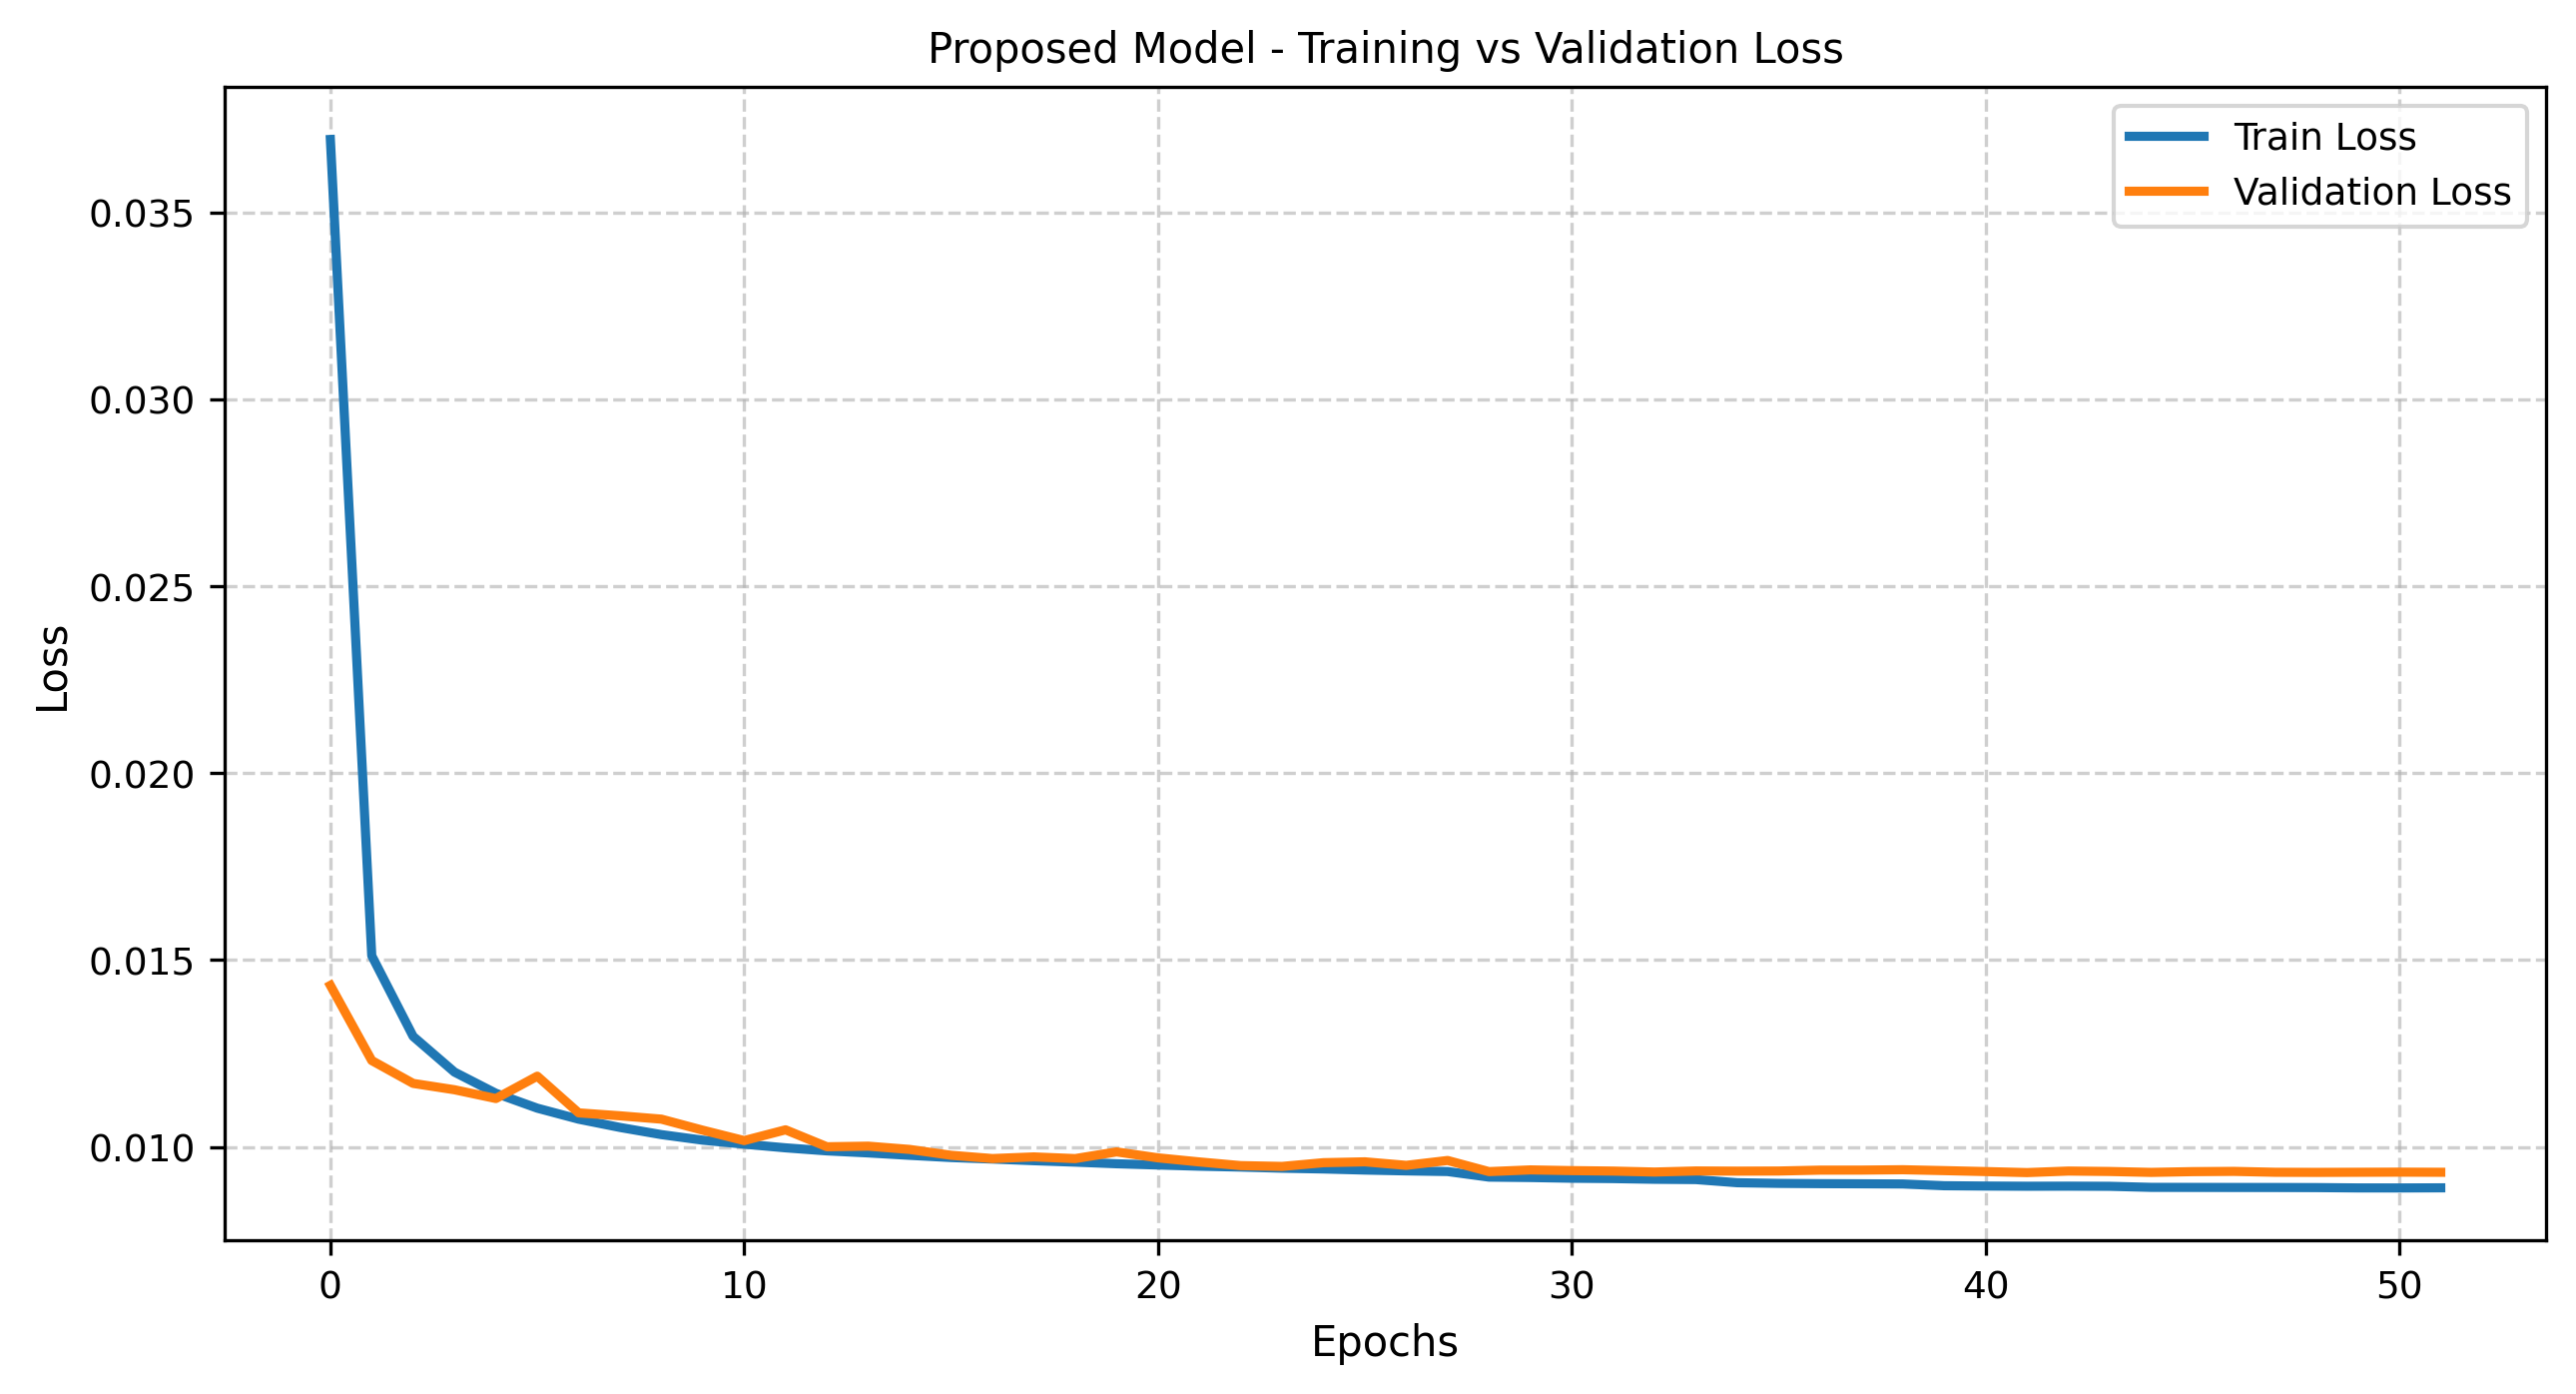

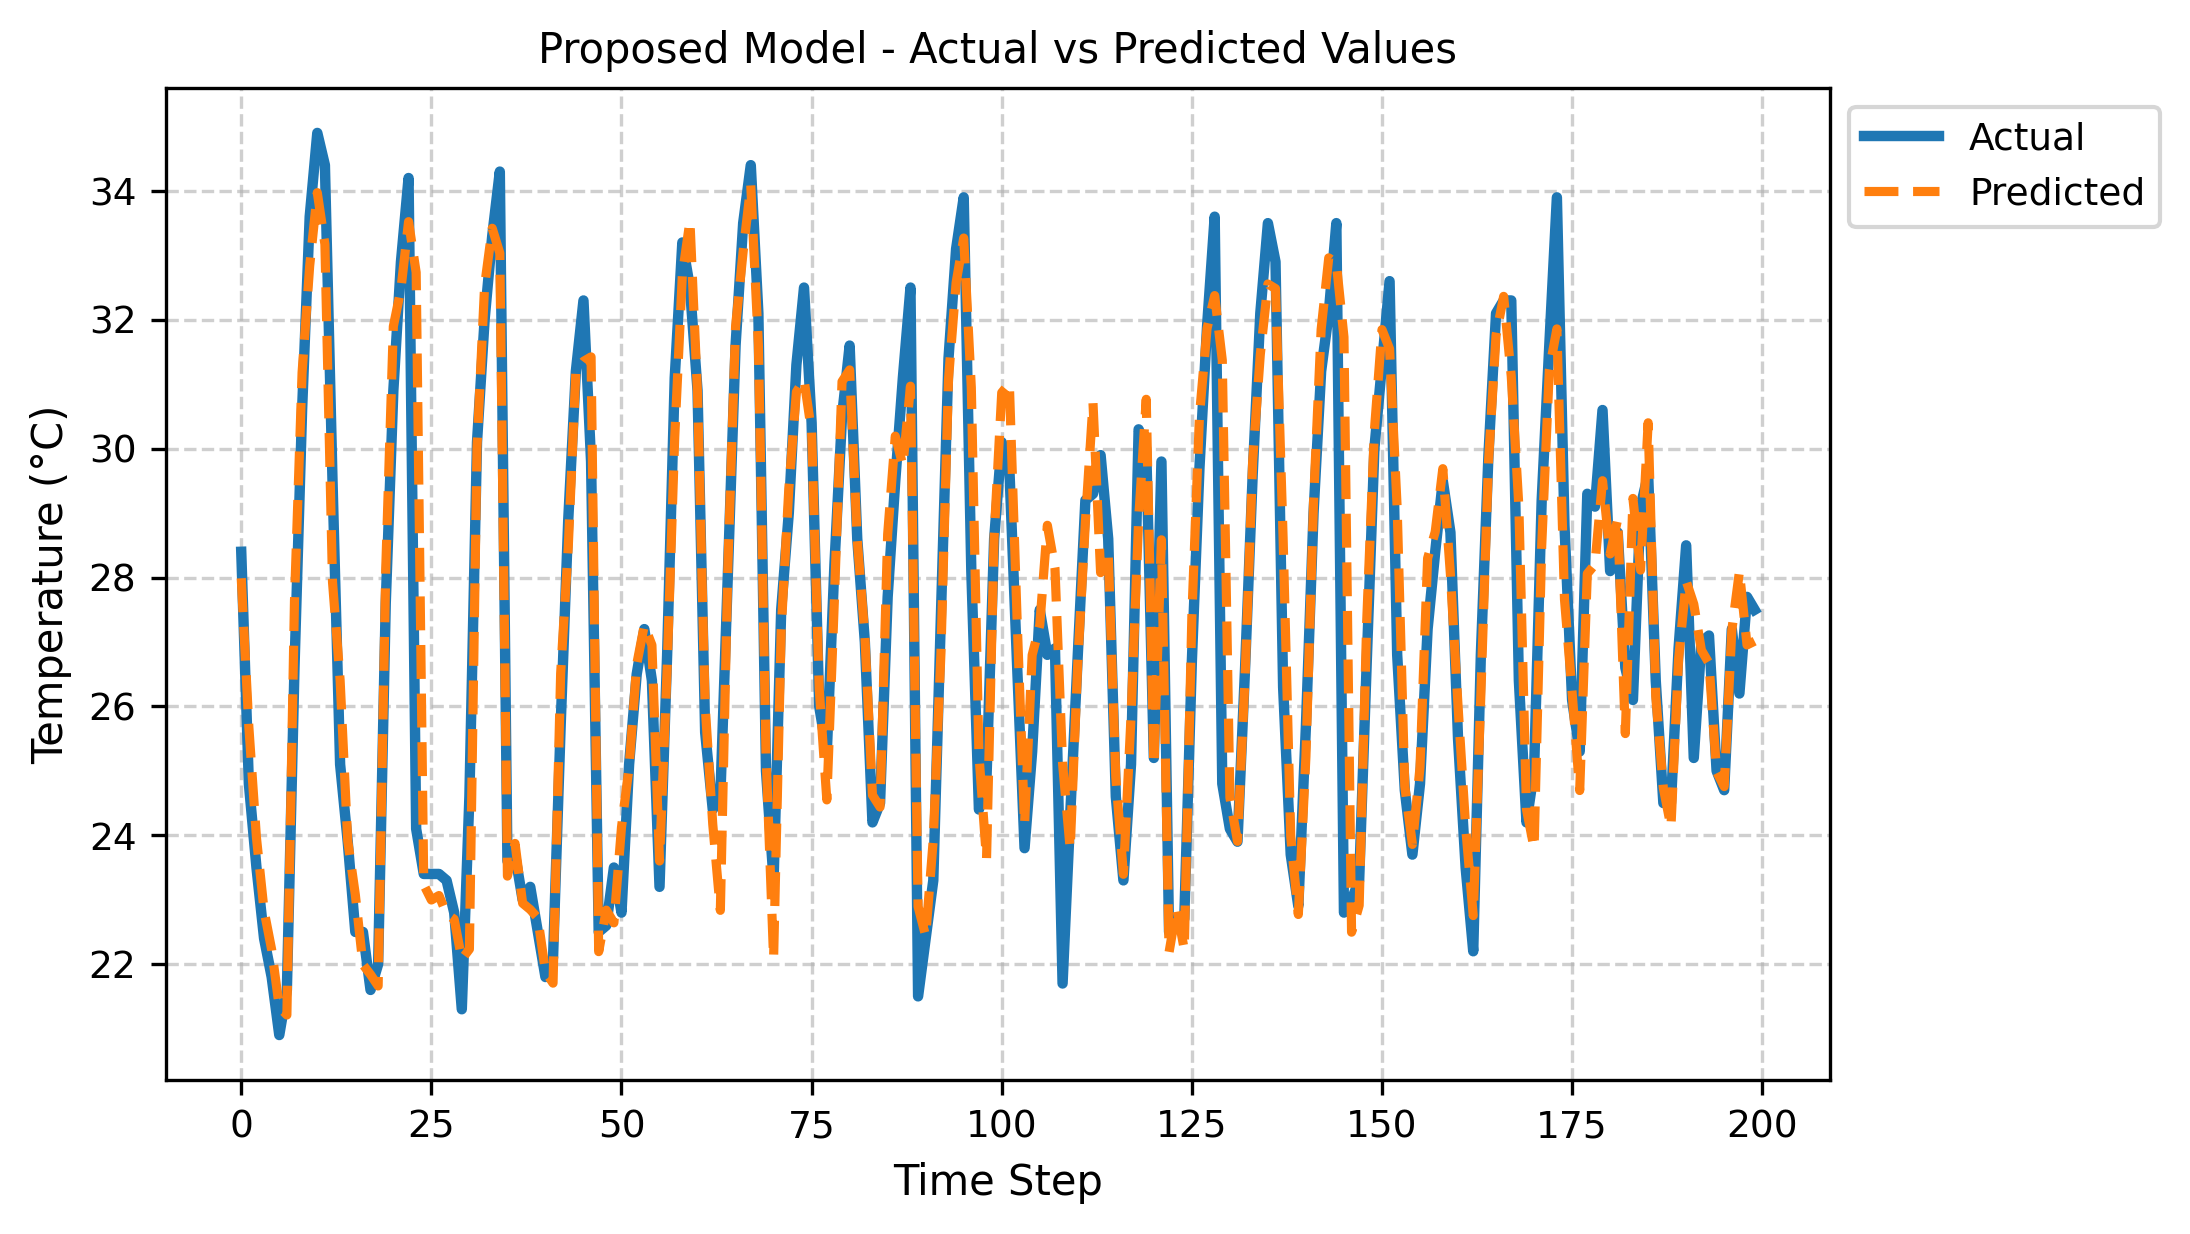

In [27]:

# LOAD MODEL

model_proposed = load_model(
    "models/cnn_bilstm_residual_attention_temperature_v8.keras",
    custom_objects={
        "ResidualTemporalAttentionV8": ResidualTemporalAttentionV8,
        "composite_loss_v8": composite_loss_v8
    },
    compile=False
)


# LOAD HISTORY (FIXED PATH)

history_proposed = joblib.load(
    "history/cnn_bilstm_residual_attention_v8_history.pkl"
)


# PREDICT

y_pred_proposed = model_proposed.predict(X_test_seq)

y_pred_proposed_actual = scaler_y.inverse_transform(y_pred_proposed)
y_test_actual = scaler_y.inverse_transform(y_test_seq)


# PLOT

plot_loss(history_proposed, "Proposed Model")

plot_actual_vs_predicted(
    y_test_actual,
    y_pred_proposed_actual,
    "Proposed Model"
)

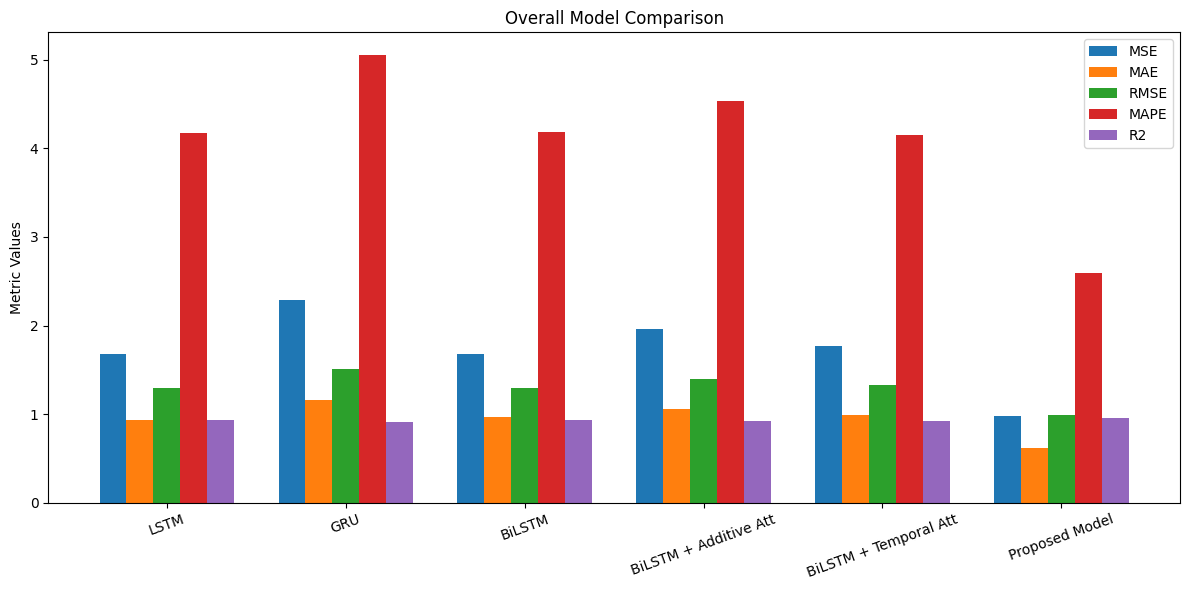

In [30]:
models = [
    "LSTM",
    "GRU",
    "BiLSTM",
    "BiLSTM + Additive Att",
    "BiLSTM + Temporal Att",
    "Proposed Model"
]

mse  = [1.6754, 2.2849, 1.6751, 1.9631, 1.7665, 0.9755]
mae  = [0.9337, 1.1646, 0.9666, 1.0592, 0.9908, 0.6155]
rmse = [1.2943, 1.5116, 1.2942, 1.4011, 1.3291, 0.9876]
mape = [4.1700, 5.0579, 4.1903, 4.5309, 4.1561, 2.5972]
r2   = [0.9307, 0.9055, 0.9307, 0.9188, 0.9269, 0.9596]

# ======================
# COMBINED GRAPH
# ======================

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(12,6))

plt.bar(x - 2*width, mse,  width, label='MSE')
plt.bar(x - width,  mae,  width, label='MAE')
plt.bar(x,          rmse, width, label='RMSE')
plt.bar(x + width,  mape, width, label='MAPE')
plt.bar(x + 2*width,r2,   width, label='R2')

plt.xticks(x, models, rotation=20)
plt.title("Overall Model Comparison")
plt.ylabel("Metric Values")
plt.legend()

plt.tight_layout()

plt.show()